# ANLP Project

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

import torch
import torch.nn.functional as F

from transformers import BertTokenizer, BertForMaskedLM

from scipy import stats as sps
from scipy.stats import entropy, mannwhitneyu, kruskal, pearsonr

from scipy.spatial.distance import jensenshannon

from sklearn.metrics import cohen_kappa_score


import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# Setup

## Models

### ngram
Based on scraped data from the German web, cleaned, plurals extracted, endings extracted. Ending distributions are similar to those reported in Sonnenstuhl & Huth (2002) and Penke & Krause (2002). Since -s is reported to be replacing zero endings, it is expected that -s frequency will have increased since 2002. -r is no longer productive, so a low frequency is expected.
- Sonnenstuhl & Huth (2002:278, Table 1), counted in the CELEX lexical database: -n: 48%, -e: 27%; -Ø: 17%, -er and –s: both 4%.
- Penke & Krause (2002:304): most frequent n > e > Ø > r > s least frequent

Bigrams and trigrams seem to have similar probabilities. Following Divjak et al (2021)'s use of final trigrams, we also use trigrams.

In [2]:
corpus = pd.read_csv('./deweb21_data.csv')
print(corpus.shape)
print(corpus['class_label'].describe())
print(corpus['lemma'].describe())
corpus.head()

(1165162, 6)
count     1165162
unique          5
top             n
freq       656734
Name: class_label, dtype: object
count     1165162
unique     175587
top         Datum
freq        20572
Name: lemma, dtype: object


,sentence,plurals,plural_word,lemma,class_label,label_id
0,100 Rabatt auf ein Lernen Zertifizierung Kurs ...,Rabatt,Rabatt,Rabatt,0,0
1,100 Virgin Resin Shrink Wrap mit maximalen UV-...,UV-Hemmern,UV-Hemmern,UV-Hemmer,n,1
2,10-Kandidaten müssen es nicht sein aber sie so...,"10-Kandidaten, Noten",10-Kandidaten,10-Kandidaten,0,0
3,10-Kandidaten müssen es nicht sein aber sie so...,"10-Kandidaten, Noten",Noten,Note,n,1
4,10 Seiten gepunktete Rasterseiten für Notizen ...,"Seiten, Rasterseiten, Notizen, Ecken",Seiten,Seite,n,1


/var/folders/hn/q9w6s4r106lfb4wbldhkqtwr0000gp/T/ipykernel_16233/3106059220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_percentages.values, palette='viridis', edgecolor='black')


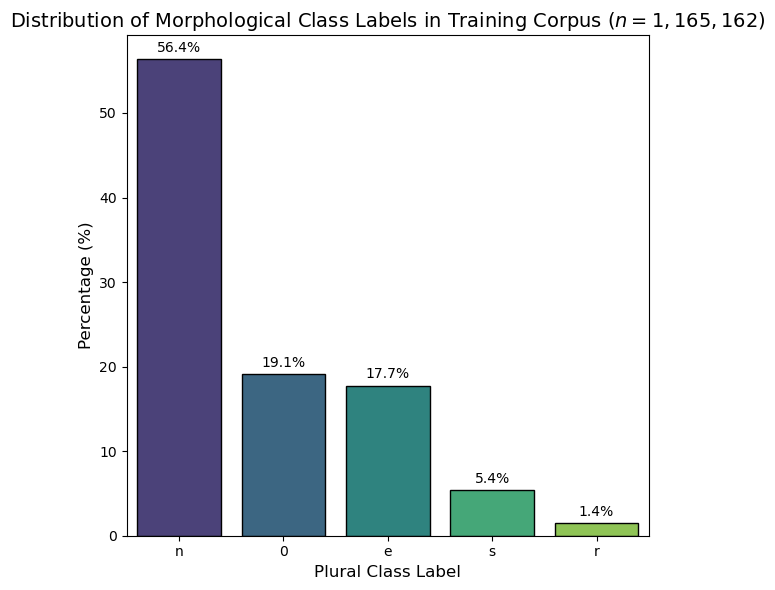

In [3]:
# ending distribution in the corpus
label_counts = corpus['class_label'].value_counts().sort_values(ascending=False)
label_percentages = (label_counts / label_counts.sum()) * 100

plt.figure(figsize=(6, 6))
sns.barplot(x=label_counts.index, y=label_percentages.values, palette='viridis', edgecolor='black')
plt.title(r'Distribution of Morphological Class Labels in Training Corpus ($n=1,165,162$)', fontsize=14)
plt.xlabel('Plural Class Label', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Bar labels
for i, (count, pct) in enumerate(zip(label_counts.values, label_percentages.values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [4]:
def ngrams(corpus, n=3):
    #count canonical plural endings for final trigrams
    counts = defaultdict(Counter)
    for _, row in corpus.iterrows():
        stem_end = str(row['lemma'])[-3:].lower() #final ngram of the lemma
        counts[stem_end][row['class_label']] += 1 #canonical plural ending

    #get probabilities
    df_probs = pd.DataFrame(counts).fillna(0) #fill NaN with 0
    df_probs = df_probs / df_probs.sum(axis=0) #normalise
    df_probs = df_probs.T # transpose so it's easier to read

    return df_probs

In [5]:
# trigrams = ngrams(corpus, n=3)
# print(trigrams.shape)
# trigrams.to_csv('trigram_model.csv')
# trigrams.head()

In [6]:
# bigrams = ngrams(corpus, n=2)
# print(bigrams.shape)
# bigrams.head()

### BERT

In [7]:
# ==Gbert Model and Tokenizer==
gbert = "deepset/gbert-base"
gbert_tokenizer = BertTokenizer.from_pretrained(gbert)
gbert_model = BertForMaskedLM.from_pretrained(gbert, output_attentions=True) #make sure attention is included

# ==Mbert Model and Tokenizer==
mbert = "bert-base-multilingual-cased"
mbert_tokenizer = BertTokenizer.from_pretrained(mbert)
mbert_model = BertForMaskedLM.from_pretrained(mbert, output_attentions=True)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: deepset/gbert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Stimuli
Cloze sentences and human data from experiment with German native speakers from Molloy (2018)

In [8]:
# ==Suffix IDs==
suffix_map = {"n": "##n", "s": "##s", "e": "##e", "r": "##r", "0": "."}
endings = list(suffix_map.keys())
suffixes = list(suffix_map.values())

gbert_suffix_ids = {k: gbert_tokenizer.convert_tokens_to_ids(v) for k, v in suffix_map.items()}
mbert_suffix_ids = {k: mbert_tokenizer.convert_tokens_to_ids(v) for k, v in suffix_map.items()}

# Verify plural suffixes exist in BERT vocabulary
def suffixes_in_vocab(suffixes=suffixes, tokenizer=gbert_tokenizer):
    unk_id = tokenizer.unk_token_id
    for s in suffixes:
        s_id = tokenizer.convert_tokens_to_ids(s)
        status = "In vocab" if s_id != unk_id else "Not in vocab"
        print(f"Token: {s:<5} | ID: {s_id:<6} | Status: {status}")

print(gbert)
suffixes_in_vocab()
print(mbert)
suffixes_in_vocab(tokenizer=mbert_tokenizer)

deepset/gbert-base
Token: ##n   | ID: 30882  | Status: In vocab
Token: ##s   | ID: 30886  | Status: In vocab
Token: ##e   | ID: 30881  | Status: In vocab
Token: ##r   | ID: 30884  | Status: In vocab
Token: .     | ID: 566    | Status: In vocab
bert-base-multilingual-cased
Token: ##n   | ID: 10115  | Status: In vocab
Token: ##s   | ID: 10107  | Status: In vocab
Token: ##e   | ID: 10112  | Status: In vocab
Token: ##r   | ID: 10129  | Status: In vocab
Token: .     | ID: 119    | Status: In vocab


In [9]:
plural_stimuli = {
    # --- Alternations ---
    "Park": {"condition": "alternation", "cloze": "Es gibt viele [MASK] in Berlin.", "gender": "der", "umlautable": True, "stressed_stem": True},
    "Biskuit": {"condition": "alternation", "cloze": "Ich habe gestern zwanzig [MASK] gebacken.", "gender": "der", "umlautable": False, "stressed_stem": True},
    "Jodel": {"condition": "alternation", "cloze": "Max postet mindestens fünf [MASK] jeden Tag.", "gender": "der", "umlautable": True, "stressed_stem": False},
    "Schal": {"condition": "alternation", "cloze": "Monika hat viele [MASK] in ihrem Schrank.", "gender": "der", "umlautable": True, "stressed_stem": True},
    "Test": {"condition": "alternation", "cloze": "Schüler müssen heutzutage so viele [MASK] schreiben.", "gender": "der", "umlautable": False, "stressed_stem": True},
    "Boykott": {"condition": "alternation", "cloze": "Die meisten [MASK] sind politisch motiviert.", "gender": "der", "umlautable": True, "stressed_stem": True},
    "Kabarett": {"condition": "alternation", "cloze": "[MASK] sind ein Teil des Alltags...", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Bukett": {"condition": "alternation", "cloze": "\"Wie viele [MASK] muss ich dir geben...\"", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Labor": {"condition": "alternation", "cloze": "Da ihr Arbeitsplatz so viele [MASK] hat...", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Fazit": {"condition": "alternation", "cloze": "Wie viele [MASK] kann man aus einem Text ziehen?!", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Limit": {"condition": "alternation", "cloze": "Es gibt keine [MASK]!", "gender": "das", "umlautable": False, "stressed_stem": True},
    "Konto": {"condition": "alternation", "cloze": "Wie viele [MASK] darf man haben?", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Pastorale": {"condition": "alternation", "cloze": "Diese zwei [MASK] sind einfach wunderschön.", "gender": "die", "umlautable": True, "stressed_stem": False},
    "Datscha": {"condition": "alternation", "cloze": "Es gibt viele [MASK] auf dem Land...", "gender": "die", "umlautable": True, "stressed_stem": False},
    "Playlist": {"condition": "alternation", "cloze": "Die Vanessa hat so viele [MASK] auf Spotify!", "gender": "die", "umlautable": False, "stressed_stem": True},

    # --- Real ---
    "Tafel": {"condition": "real", "cloze": "Das Schulbudget ist nicht groß genug...", "gender": "die", "umlautable": True, "stressed_stem": False},
    "Lawine": {"condition": "real", "cloze": "[MASK] kommen im Winter oft vor.", "gender": "die", "umlautable": False, "stressed_stem": False},
    "Wartezeit": {"condition": "real", "cloze": "Die [MASK] beim Arzt sind oft echt lange.", "gender": "die", "umlautable": False, "stressed_stem": True},
    "Teppich": {"condition": "real", "cloze": "Unser Kunde braucht mindestens zehn [MASK].", "gender": "der", "umlautable": False, "stressed_stem": False},
    "Hase": {"condition": "real", "cloze": "Auf dem Rasen waren nur [MASK] zu sehen.", "gender": "der", "umlautable": True, "stressed_stem": False},
    "Untertitel": {"condition": "real", "cloze": "Die [MASK] in diesem Film sind...", "gender": "der", "umlautable": True, "stressed_stem": False},
    "Freizeichen": {"condition": "real", "cloze": "[MASK] sind in jedem Land anders.", "gender": "das", "umlautable": False, "stressed_stem": False},
    "Becken": {"condition": "real", "cloze": "Unser Schwimmbad hat viele [MASK].", "gender": "das", "umlautable": False, "stressed_stem": False},
    "Kissen": {"condition": "real", "cloze": "er hat immer so viele [MASK] auf seiner Couch.", "gender": "das", "umlautable": False, "stressed_stem": False},

    # --- Nonce ---
    "Gupel": {"condition": "nonce", "cloze": "Annika hat ihre zwei [MASK] geputzt.", "gender": "die", "umlautable": True, "stressed_stem": False},
    "Maffer": {"condition": "nonce", "cloze": "Wann habt ihr zum letzten Mal zwei [MASK] gesehen?", "gender": "die", "umlautable": True, "stressed_stem": False},
    "Morfett": {"condition": "nonce", "cloze": "Ich habe euch schon erzählt...", "gender": "die", "umlautable": True, "stressed_stem": True},
    "Trilit": {"condition": "nonce", "cloze": "Lukas hat viele [MASK] bei sich Zuhause...", "gender": "die", "umlautable": False, "stressed_stem": True},
    "Knidoka": {"condition": "nonce", "cloze": "Wir have gestern über [MASK] gelesen.", "gender": "die", "umlautable": False, "stressed_stem": False},
    "Grimzo": {"condition": "nonce", "cloze": "Hast du die drei [MASK] gefunden?", "gender": "die", "umlautable": False, "stressed_stem": False},
    "Trichel": {"condition": "nonce", "cloze": "Gert und Birgit dachten...", "gender": "der", "umlautable": False, "stressed_stem": False},
    "Pflechter": {"condition": "nonce", "cloze": "seine Werbung für [MASK] gelaufen ist!", "gender": "der", "umlautable": False, "stressed_stem": False},
    "Cherpak": {"condition": "nonce", "cloze": "Mehrere [MASK] habe ich aber nie zusammen gesehen.", "gender": "der", "umlautable": True, "stressed_stem": True},
    "Kniempe": {"condition": "nonce", "cloze": "Kathi war richtig froh...", "gender": "der", "umlautable": False, "stressed_stem": False},
    "Pommeng": {"condition": "nonce", "cloze": "Lena hat die [MASK] weggemacht.", "gender": "der", "umlautable": True, "stressed_stem": True},
    "Sampa": {"condition": "nonce", "cloze": "Kevin seine [MASK] auf dem Tisch stehen lässt!", "gender": "der", "umlautable": True, "stressed_stem": False},
    "Fliffel": {"condition": "nonce", "cloze": "Wo kann man gute [MASK] finden?", "gender": "das", "umlautable": False, "stressed_stem": False},
    "Deipfer": {"condition": "nonce", "cloze": "Hast du Julia schon die [MASK] gegeben?", "gender": "das", "umlautable": False, "stressed_stem": False},
    "Istrat": {"condition": "nonce", "cloze": "[MASK] sind meiner Meinung nach echt eklig.", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Virong": {"condition": "nonce", "cloze": "Mama sagt, dass [MASK] gut für die Gesundheit sind.", "gender": "das", "umlautable": True, "stressed_stem": True},
    "Nofte": {"condition": "nonce", "cloze": "Jedes Haus soll ein paar gute [MASK] haben!", "gender": "das", "umlautable": True, "stressed_stem": False},
    "Brolck": {"condition": "nonce", "cloze": "Sophie verlässt das Haus nie ohne [MASK].", "gender": "das", "umlautable": True, "stressed_stem": True}
}

## Experiment 

In [10]:
def calculate_metrics(row):
    probs = np.array([p for p in row if p > 0]) # Filter probabilities > 0 to avoid log(0) errors
    
    # Shannon Entropy: average uncertainty
    log_probs = np.log2(probs)
    entropy = -np.sum(probs * log_probs)
    
    # Varentropy: variance in uncertainty
    varentropy = np.sum(probs * (log_probs + entropy)**2)
    
    # Confidence
    max_entropy = np.log2(5) #5 plural classes
    confidence = 1 - (entropy / max_entropy) # Normalized inverse entropy (1 = total certainty, 0 = uniform distribution)
    
    return pd.Series({
        'entropy': entropy,
        'varentropy': varentropy,
        'confidence': confidence
    })

def calc_r2(df, var1,var2):
    clean_df = df[[var1, var2]].dropna()
    x = clean_df[var1]
    y = clean_df[var2]

    slope, intercept, r_value, p_value, std_err = sps.linregress(x, y)
    r_squared = r_value**2

    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Slope: {slope:.4f}")

### Humans

In [11]:
# Human answers
humans_df = pd.read_csv('./human_responses_pct.csv')

humans_df = humans_df.drop('row_total_pct', axis=1)
humans_df = humans_df.drop('Unnamed: 0', axis=1)
humans_df = humans_df.drop('index', axis=1)

new_index_labels = list(plural_stimuli.keys()) 
humans_df.index = [i for i in new_index_labels]

#add human preference col
numeric_df = humans_df.select_dtypes(include=['number'])
humans_df['hum_winner'] = numeric_df.idxmax(axis=1)
humans_df['hum_winner'] = humans_df['hum_winner'].str.replace('_pct', '').str.replace('prob_', '')
humans_df.head()

,0_pct,n_pct,e_pct,s_pct,r_pct,hum_winner
Park,0.00,0.00,2.30,97.70,0.00,s
Biskuit,9.59,0.91,2.28,87.21,0.00,s
Jodel,70.70,10.70,0.00,14.88,3.72,0
Schal,0.91,0.00,6.85,92.24,0.00,s
Test,0.46,0.00,3.20,96.35,0.00,s


In [12]:
#change percentages to probabilities
humans_df['0_prob'] = humans_df['0_pct'] / 100
humans_df['n_prob'] = humans_df['n_pct'] / 100
humans_df['s_prob'] = humans_df['s_pct'] / 100
humans_df['r_prob'] = humans_df['r_pct'] / 100
humans_df['e_prob'] = humans_df['e_pct'] / 100

#calculate uncertainty metrics
human_probs = humans_df[['0_prob', 'n_prob', 'e_prob', 's_prob', 'r_prob']]
human_probs = human_probs.apply(calculate_metrics, axis=1)
humans_df = pd.concat([humans_df, human_probs], axis=1)
humans_df.head()

,0_pct,n_pct,e_pct,s_pct,r_pct,hum_winner,0_prob,n_prob,s_prob,r_prob,e_prob,entropy,varentropy,confidence
Park,0.00,0.00,2.30,97.70,0.00,s,0.0000,0.0000,0.9770,0.0000,0.0230,0.157969,0.657356,0.931967
Biskuit,9.59,0.91,2.28,87.21,0.00,s,0.0959,0.0091,0.8721,0.0000,0.0228,0.682615,1.761811,0.706014
Jodel,70.70,10.70,0.00,14.88,3.72,0,0.7070,0.1070,0.1488,0.0372,0.0000,1.284287,1.602837,0.446888
Schal,0.91,0.00,6.85,92.24,0.00,s,0.0091,0.0000,0.9224,0.0000,0.0685,0.434131,1.267086,0.813030
Test,0.46,0.00,3.20,96.35,0.00,s,0.0046,0.0000,0.9635,0.0000,0.0320,0.246306,1.008498,0.893922


In [13]:
humans_df.to_csv('./results/humans_results.csv')

Mean Certainty Metrics by Condition:
             entropy  varentropy  confidence
condition                                   
alternation    0.799       1.033       0.656
nonce          1.295       1.132       0.442
real           0.039       0.171       0.983


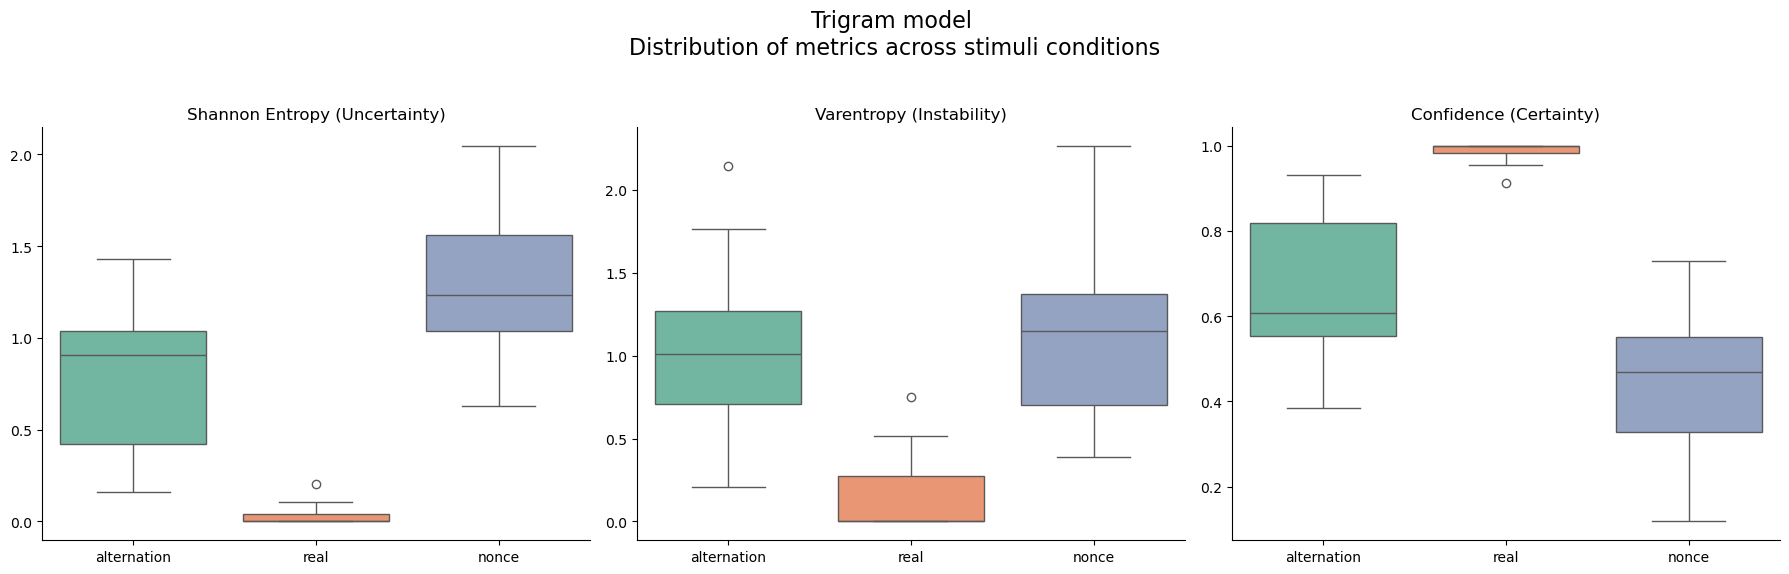

In [14]:
#boxplots of confidence/certainty metrics
df_meta = pd.DataFrame.from_dict(plural_stimuli, orient='index')
comparison_df = df_meta.join(humans_df[['entropy', 'varentropy', 'confidence']])
stats = comparison_df.groupby('condition')[['entropy', 'varentropy', 'confidence']].mean()

print("Mean Certainty Metrics by Condition:")
print(stats.round(3))

#plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
metrics = ['entropy', 'varentropy', 'confidence']
titles = ['Shannon Entropy (Uncertainty)', 'Varentropy (Instability)', 'Confidence (Certainty)']

for i, metric in enumerate(metrics):
    sns.boxplot(ax=axes[i], data=comparison_df, x='condition', y=metric, hue='condition', palette='Set2', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Trigram model \nDistribution of metrics across stimuli conditions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

### Trigram
- alternations: highest entropy, lowest confidence
- nonce: widest range
- most confusing: Grimzo
- significant positive relationship between varentropy and frequency (r2=0.1610, p=0.0085) - ie, higher frequency leads to more unstable or "peaky" uncertainty, learns that they are consistently and chaotically ambiguous because of morphological competition

In [15]:
trigrams = pd.read_csv('trigram_model.csv')
trigrams = trigrams.rename(columns={'Unnamed: 0': 'trigram'}).set_index('trigram')
trigrams.index.name = None
trigrams.head()

,0,n,e,r,s
att,0.049960,0.594766,0.199048,0.156225,0.000000
mer,0.715750,0.277619,0.004974,0.000301,0.001356
ten,0.973215,0.024388,0.001980,0.000000,0.000417
ote,0.344318,0.654545,0.001136,0.000000,0.000000
ite,0.092934,0.898562,0.000000,0.000000,0.008504


In [16]:
test_list = list(plural_stimuli.keys())

distributions = []
for word in test_list:
    final_trigram = word[-3:].lower()
    if final_trigram in trigrams.index:
        dist = trigrams.loc[final_trigram].to_dict()
    else:
        dist = {col: 1/len(trigrams.columns) for col in trigrams.columns} #uniform prior
    distributions.append(dist)

trigrams_df = pd.DataFrame(distributions, index=test_list)
trigrams_df.head()

,0,n,e,r,s
Park,0.005076,0.243655,0.271574,0.000000,0.479695
Biskuit,0.053097,0.610619,0.269912,0.008850,0.057522
Jodel,0.100000,0.730357,0.016071,0.000000,0.153571
Schal,0.024194,0.491935,0.395161,0.000000,0.088710
Test,0.068582,0.076628,0.105747,0.002682,0.746360


In [17]:
tri_metrics_df = trigrams_df.apply(calculate_metrics, axis=1)
trigrams_df['winner'] = trigrams_df[['0', 'n', 'e', 'r', 's',]].idxmax(axis=1)
trigrams_df = pd.concat([trigrams_df, tri_metrics_df], axis=1)
trigrams_df.head()

,0,n,e,r,s,winner,entropy,varentropy,confidence
Park,0.005076,0.243655,0.271574,0.000000,0.479695,s,1.554140,0.389892,0.330668
Biskuit,0.053097,0.610619,0.269912,0.008850,0.057522,n,1.466743,1.461823,0.368308
Jodel,0.100000,0.730357,0.016071,0.000000,0.153571,n,1.174164,1.567750,0.494315
Schal,0.024194,0.491935,0.395161,0.000000,0.088710,n,1.472709,0.836335,0.365739
Test,0.068582,0.076628,0.105747,0.002682,0.746360,s,1.229800,2.004721,0.470354


In [18]:
trigrams_df.to_csv('./results/trigrams_results.csv')

Mean Certainty Metrics by Condition:
             entropy  varentropy  confidence
condition                                   
alternation    1.087       1.289       0.532
nonce          0.755       0.651       0.675
real           0.635       0.916       0.726


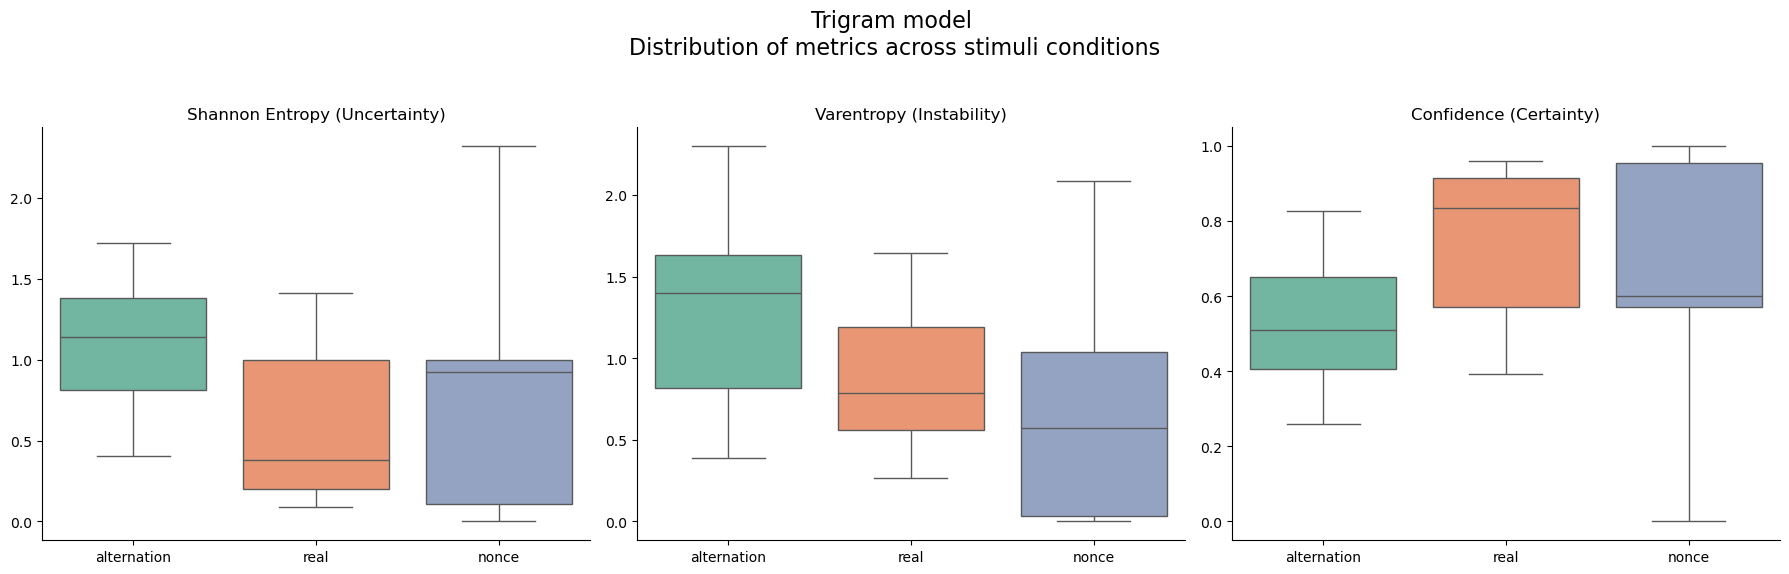

In [19]:
#boxplots of confidence/certainty metrics
df_meta = pd.DataFrame.from_dict(plural_stimuli, orient='index')
comparison_df = df_meta.join(trigrams_df[['entropy', 'varentropy', 'confidence']])
stats = comparison_df.groupby('condition')[['entropy', 'varentropy', 'confidence']].mean()

print("Mean Certainty Metrics by Condition:")
print(stats.round(3))

#plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
metrics = ['entropy', 'varentropy', 'confidence']
titles = ['Shannon Entropy (Uncertainty)', 'Varentropy (Instability)', 'Confidence (Certainty)']

for i, metric in enumerate(metrics):
    sns.boxplot(ax=axes[i], data=comparison_df, x='condition', y=metric, hue='condition', palette='Set2', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Trigram model \nDistribution of metrics across stimuli conditions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

In [20]:
#get final trigram frequency
corpus_trigram_freq = corpus['lemma'].str[-3:].str.lower().value_counts().to_dict()
comparison_df['trigram'] = [w[-3:].lower() for w in comparison_df.index]
comparison_df['frequency'] = comparison_df['trigram'].map(corpus_trigram_freq).fillna(0)
comparison_df['log_frequency'] = np.log10(comparison_df['frequency'] + 1)
comparison_df.head()

,condition,cloze,gender,umlautable,stressed_stem,entropy,varentropy,confidence,trigram,frequency,log_frequency
Park,alternation,Es gibt viele [MASK] in Berlin.,der,True,True,1.554140,0.389892,0.330668,ark,788.0,2.897077
Biskuit,alternation,Ich habe gestern zwanzig [MASK] gebacken.,der,False,True,1.466743,1.461823,0.368308,uit,226.0,2.356026
Jodel,alternation,Max postet mindestens fünf [MASK] jeden Tag.,der,True,False,1.174164,1.567750,0.494315,del,560.0,2.748963
Schal,alternation,Monika hat viele [MASK] in ihrem Schrank.,der,True,True,1.472709,0.836335,0.365739,hal,124.0,2.096910
Test,alternation,Schüler müssen heutzutage so viele [MASK] schr...,der,False,True,1.229800,2.004721,0.470354,est,2610.0,3.416807


In [21]:
print('freq vs entropy')
calc_r2(comparison_df,'log_frequency','entropy')
print('\n freq vs varentropy')
calc_r2(comparison_df,'log_frequency','varentropy')
print('\n freq vs confidence')
calc_r2(comparison_df,'log_frequency','confidence')

freq vs entropy
R-squared: 0.0051
P-value: 0.6527
Slope: -0.0378

 freq vs varentropy
R-squared: 0.1610
P-value: 0.0085
Slope: 0.2531

 freq vs confidence
R-squared: 0.0051
P-value: 0.6527
Slope: 0.0163


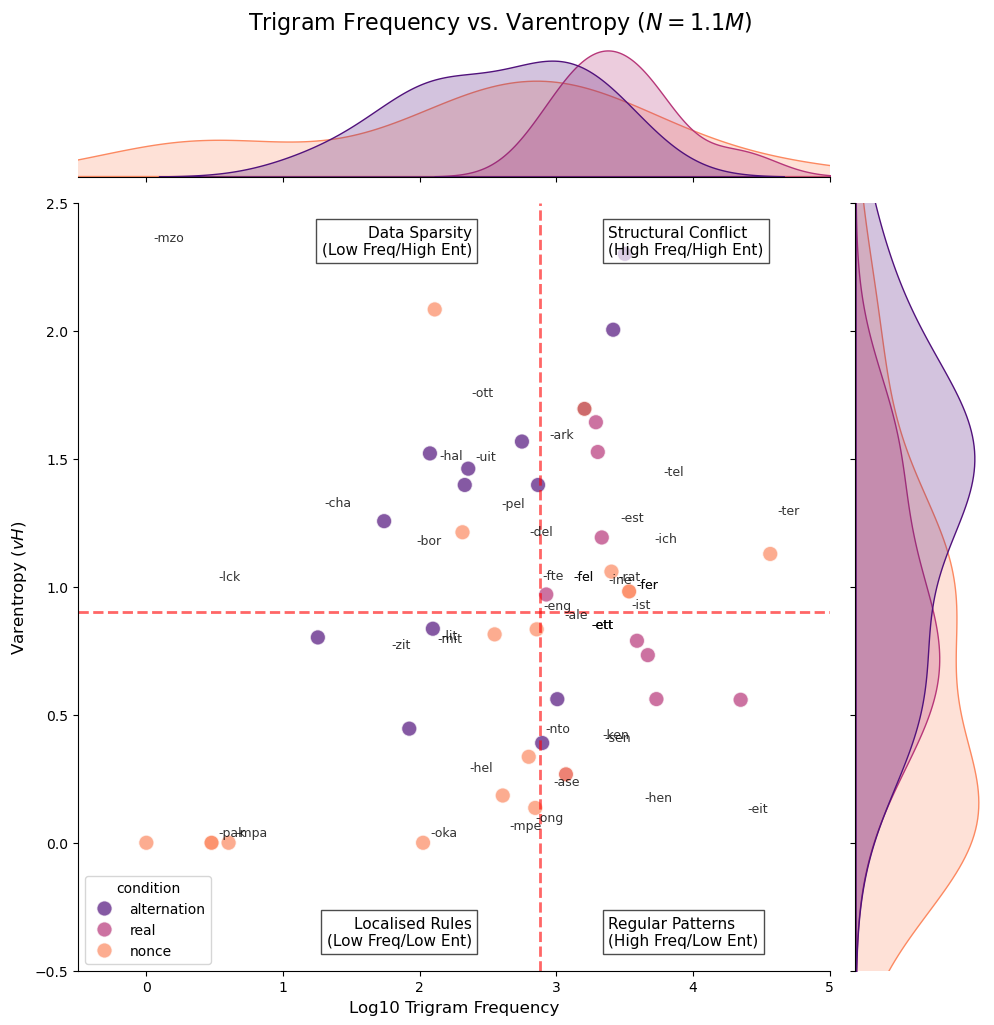

In [22]:
#varentropy vs freq
g = sns.jointplot(
    data=comparison_df,
    x='log_frequency',
    y='varentropy',
    hue='condition', 
    kind='scatter',
    palette='magma',
    height=10,
    joint_kws={'alpha': 0.7, 's': 120},
    xlim=(-0.5, 5), 
    ylim=(-0.5, 2.5) 
)

# Median Quadrant Lines 
med_freq = comparison_df['log_frequency'].median()
med_ent = comparison_df['varentropy'].median()

g.ax_joint.axhline(y=med_ent, color='red', linestyle='--', alpha=0.6, linewidth=2)
g.ax_joint.axvline(x=med_freq, color='red', linestyle='--', alpha=0.6, linewidth=2)

# Quadrant Labels
g.ax_joint.text(med_freq - 0.5, 2.3, "Data Sparsity\n(Low Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

g.ax_joint.text(med_freq + 0.5, 2.3, "Structural Conflict\n(High Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq + 0.5, -0.4, "Regular Patterns\n(High Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq - 0.5, -0.4, "Localised Rules\n(Low Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

# trigram labels
for i, word in enumerate(comparison_df.index):
    plt_x = comparison_df.log_frequency.iat[i]
    plt_y = comparison_df.entropy.iat[i]
    trigram = word[-3:].lower()
    g.ax_joint.annotate(
        f"-{trigram}",
        (plt_x, plt_y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        alpha=0.8
    )

g.fig.suptitle(f'Trigram Frequency vs. Varentropy ($N=1.1M$)', y=1.02, fontsize=16)
g.set_axis_labels('Log10 Trigram Frequency', 'Varentropy ($vH$)', fontsize=12)

plt.show()

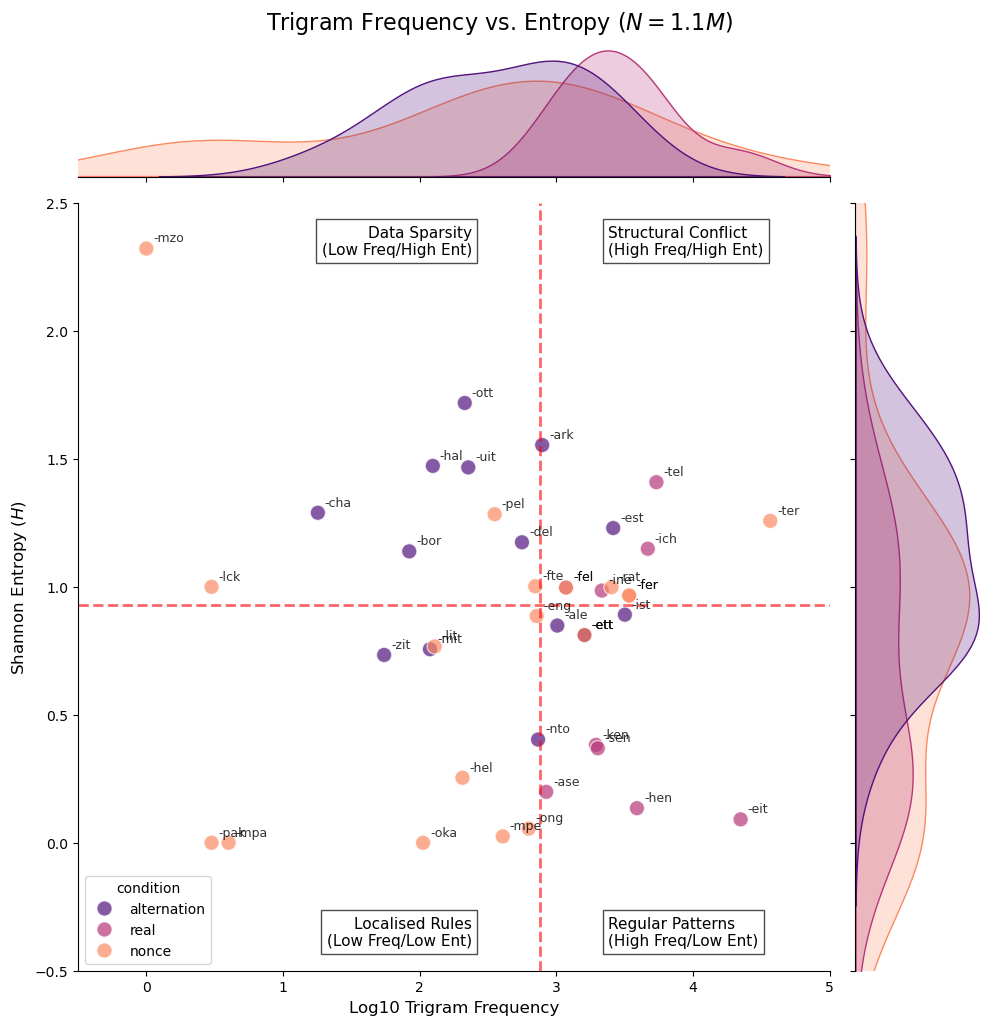

In [23]:
#entropy vs freq
g = sns.jointplot(
    data=comparison_df,
    x='log_frequency',
    y='entropy',
    hue='condition', 
    kind='scatter',
    palette='magma',
    height=10,
    joint_kws={'alpha': 0.7, 's': 120},
    xlim=(-0.5, 5), 
    ylim=(-0.5, 2.5) 
)

# Median Quadrant Lines 
med_freq = comparison_df['log_frequency'].median()
med_ent = comparison_df['entropy'].median()

g.ax_joint.axhline(y=med_ent, color='red', linestyle='--', alpha=0.6, linewidth=2)
g.ax_joint.axvline(x=med_freq, color='red', linestyle='--', alpha=0.6, linewidth=2)

#Quadrant Labels
g.ax_joint.text(med_freq - 0.5, 2.3, "Data Sparsity\n(Low Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

g.ax_joint.text(med_freq + 0.5, 2.3, "Structural Conflict\n(High Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq + 0.5, -0.4, "Regular Patterns\n(High Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq - 0.5, -0.4, "Localised Rules\n(Low Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

#trigram labels
for i, word in enumerate(comparison_df.index):
    plt_x = comparison_df.log_frequency.iat[i]
    plt_y = comparison_df.entropy.iat[i]
    trigram = word[-3:].lower()
    g.ax_joint.annotate(
        f"-{trigram}",
        (plt_x, plt_y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        alpha=0.8
    )

g.fig.suptitle(f'Trigram Frequency vs. Entropy ($N=1.1M$)', y=1.02, fontsize=16)
g.set_axis_labels('Log10 Trigram Frequency', 'Shannon Entropy ($H$)', fontsize=12)

plt.show()

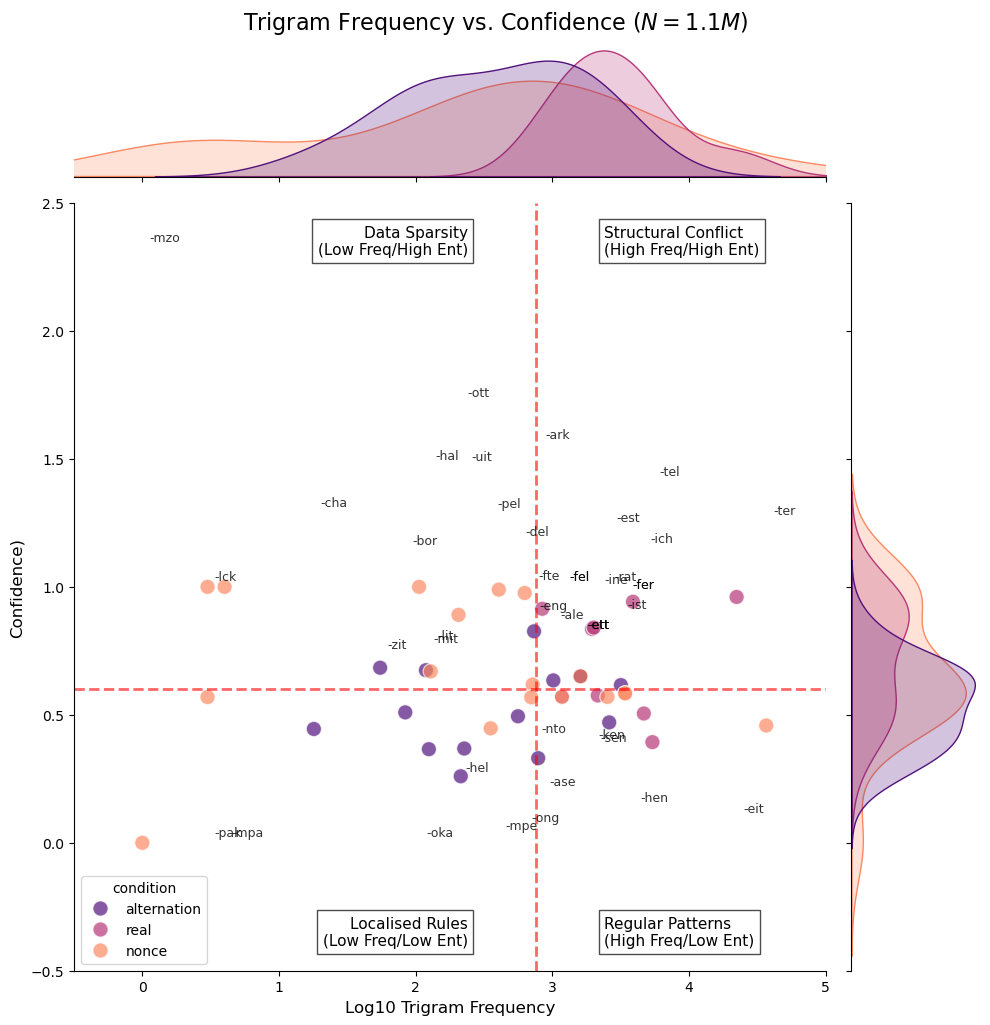

In [24]:
#confidence vs freq
g = sns.jointplot(
    data=comparison_df,
    x='log_frequency',
    y='confidence',
    hue='condition', 
    kind='scatter',
    palette='magma',
    height=10,
    joint_kws={'alpha': 0.7, 's': 120},
    xlim=(-0.5, 5), 
    ylim=(-0.5, 2.5) 
)

# Median Quadrant Lines 
med_freq = comparison_df['log_frequency'].median()
med_ent = comparison_df['confidence'].median()

g.ax_joint.axhline(y=med_ent, color='red', linestyle='--', alpha=0.6, linewidth=2)
g.ax_joint.axvline(x=med_freq, color='red', linestyle='--', alpha=0.6, linewidth=2)

#Quadrant Labels
g.ax_joint.text(med_freq - 0.5, 2.3, "Data Sparsity\n(Low Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

g.ax_joint.text(med_freq + 0.5, 2.3, "Structural Conflict\n(High Freq/High Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq + 0.5, -0.4, "Regular Patterns\n(High Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='left')

g.ax_joint.text(med_freq - 0.5, -0.4, "Localised Rules\n(Low Freq/Low Ent)", 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.7), ha='right')

#trigram labels
for i, word in enumerate(comparison_df.index):
    plt_x = comparison_df.log_frequency.iat[i]
    plt_y = comparison_df.entropy.iat[i]
    trigram = word[-3:].lower()
    g.ax_joint.annotate(
        f"-{trigram}",
        (plt_x, plt_y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        alpha=0.8
    )

g.fig.suptitle(f'Trigram Frequency vs. Confidence ($N=1.1M$)', y=1.02, fontsize=16)
g.set_axis_labels('Log10 Trigram Frequency', 'Confidence)', fontsize=12)

plt.show()

### BERT's answers

In [25]:
def get_analysis(lemma, sentence_template, endings, suffix_ids, tokenizer, model):
    """xxx"""
    model.eval()

    sentence = sentence_template.replace("[MASK]", f"{lemma}[MASK]") # Stimulus sentence frame
    
    inputs = tokenizer(sentence, return_tensors="pt") #tokenise input, return pytorch tensors

    mask_indices = (inputs.input_ids == tokenizer.mask_token_id).nonzero(as_tuple=True)[1] #finds mask in sentence via its ID and extracts token position info
    if len(mask_indices) == 0: #for the existing words the mask gets merged with the token so need to use [SEP] instead which is always at inputs.input_ids.shape[1] - 1
        mask_idx = inputs.input_ids.shape[1] - 2 
    else:
        mask_idx = mask_indices[0].item()
    
    #==Forward pass==
    with torch.no_grad(): #disable gradient calculation - unneeded
        outputs = model(**inputs) #forward pass, unpack dict to get outputs
    
    #==Examine outputs==
    logits = outputs.logits[0, mask_idx, :].squeeze() #remove 1D batch size info from logits [1, sequence length}, vocab_size]
    ending_logits = torch.stack([logits[suffix_ids[e]] for e in endings]) #logits only for endings via IDs
    
    #Softmax
    probs_tensor = torch.nn.functional.softmax(ending_logits, dim=-1) #softmax final dimension to get probabilities
    log_probs = torch.log2(probs_tensor + 1e-9)
    probs_list = probs_tensor.tolist()  #tensor to list of floats
    probs_dict = dict(zip(endings, [round(p, 4) for p in probs_list])) #map probs to endings
    
    #Uncertainty metrics
    h_total = -torch.sum(probs_tensor * torch.log2(probs_tensor + 1e-9)).item()  # Shannon entropy - uncertainty in prediction (lower = more certain), use 1e-9 to preven division by 0
    confidence = torch.max(probs_tensor).item() # probability of winning ending being correct
    varentropy = torch.sum(probs_tensor * (log_probs + h_total)**2).item() #reliability of uncertainty (high=unstable)
    
    winner = endings[torch.argmax(probs_tensor).item()] #highest prob
    
    #Attention
    final_layer_attn = outputs.attentions[-1][0, :, mask_idx, :] #4D attention tensor (Batch, Heads, From-Token, To-Token) - all heads from mask to all toks
    attn_h = -torch.sum(final_layer_attn * torch.log2(final_layer_attn + 1e-9), dim=-1).mean().item() #attention shannon entropy (high = less focus, low = more focus) - avg across all heads
    sparsity = torch.norm(final_layer_attn, p=2, dim=-1).mean().item() #Euclidean norm of attention vector (higher = more focus, lower = less focus)

    final_results ={
        "lemma": lemma,
        "prediction": winner,
        "entropy": round(h_total, 4),
        "confidence": round(confidence, 4),
        "varentropy": round(varentropy, 4),
        "attn_entropy": round(attn_h, 4),
        "attn_sparsity": round(sparsity, 4),
        "tokens": tokenizer.tokenize(lemma),
    }

    final_results.update({f"prob_{e}": probs_dict[e] for e in endings}) #dynamic update in place
    
    return final_results

# Results
- In system $N$ with 5 possible outcomes (the endings), maximum entropy $H$ is when the model assigns equal probability to each possible outcome, ie 20%, ie $\log_2(5) \approx 2.3219$. Minimum entropy would be when the model is 100% certain.
- Max entropy gbert 1.95 (Nofte) vs mbert 2.17 (Nofte, Fliffel, Gupel, Pastorale) - more entropy in mbert

### gBERT

In [26]:
gbert_results = [get_analysis(lem, val["cloze"], endings=endings, suffix_ids=gbert_suffix_ids, tokenizer=gbert_tokenizer, model=gbert_model) for lem, val in plural_stimuli.items()]
gbert_df = pd.DataFrame(gbert_results)
gbert_df

,lemma,prediction,entropy,confidence,varentropy,attn_entropy,attn_sparsity,tokens,prob_n,prob_s,prob_e,prob_r,prob_0
0,Park,e,1.0680,0.5646,0.5130,1.8089,0.6167,[Park],0.0068,0.4255,0.5646,0.0014,0.0017
1,Biskuit,e,1.1003,0.5743,0.6562,2.2984,0.5369,"[Bis, ##ku, ##it]",0.0047,0.4098,0.5743,0.0009,0.0104
2,Jodel,s,1.0138,0.7196,1.2294,2.1604,0.5608,"[Jo, ##del]",0.0194,0.7196,0.2534,0.0019,0.0058
3,Schal,s,0.5351,0.8796,0.9303,1.8346,0.6050,[Schal],0.0004,0.8796,0.1199,0.0001,0.0000
4,Test,e,0.0723,0.9918,0.4497,2.0373,0.5696,[Test],0.0004,0.0077,0.9918,0.0000,0.0002
5,Boykott,e,0.9200,0.6688,0.2712,2.1388,0.5520,"[Boy, ##ko, ##tt]",0.0003,0.3309,0.6688,0.0000,0.0000
6,Kabarett,s,1.3727,0.5087,1.1360,1.6520,0.7025,"[Kabar, ##ett]",0.0365,0.5087,0.4245,0.0077,0.0225
7,Bukett,s,0.7706,0.8579,2.0574,1.6080,0.7097,"[Buk, ##ett]",0.0239,0.8579,0.1009,0.0089,0.0083
8,Labor,e,0.6884,0.8257,0.9297,1.3019,0.7743,[Labor],0.0018,0.1719,0.8257,0.0004,0.0002
9,Fazit,s,0.8445,0.7737,1.0435,1.1739,0.7987,[Fazit],0.0098,0.7737,0.2149,0.0016,0.0001


In [27]:
gbert_df.describe()

,entropy,confidence,varentropy,attn_entropy,attn_sparsity,prob_n,prob_s,prob_e,prob_r,prob_0
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,0.959333,0.732738,1.081907,1.836619,0.640733,0.135848,0.342274,0.255779,0.025383,0.240712
std,0.652274,0.217488,0.691334,0.336751,0.088400,0.247816,0.314711,0.294787,0.056173,0.377309
min,0.000000,0.323700,0.000000,1.110400,0.507800,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.484625,0.567025,0.523900,1.596525,0.554200,0.003200,0.037875,0.024625,0.000675,0.000825
50%,0.958200,0.759750,1.023650,1.819950,0.643950,0.020450,0.278050,0.133250,0.006400,0.023300
75%,1.457525,0.924050,1.408725,2.129950,0.714600,0.098050,0.537950,0.414925,0.030050,0.274425
max,2.120600,1.000000,2.442700,2.378600,0.800000,0.931100,0.995900,0.991800,0.347300,1.000000


### mBERT

In [28]:
mbert_results = [get_analysis(lem, val["cloze"],suffix_ids=mbert_suffix_ids, endings=endings, tokenizer=mbert_tokenizer, model=mbert_model) for lem, val in plural_stimuli.items()]
mbert_df = pd.DataFrame(mbert_results)
mbert_df

,lemma,prediction,entropy,confidence,varentropy,attn_entropy,attn_sparsity,tokens,prob_n,prob_s,prob_e,prob_r,prob_0
0,Park,s,1.2072,0.7236,1.6635,2.1121,0.5838,[Park],0.0168,0.7236,0.1015,0.0018,0.1563
1,Biskuit,0,1.9157,0.4679,0.9744,1.7336,0.6972,"[Bis, ##kui, ##t]",0.2665,0.0649,0.1432,0.0575,0.4679
2,Jodel,n,0.3715,0.9501,1.7271,2.1051,0.5998,"[Jo, ##del]",0.9501,0.0067,0.0271,0.0066,0.0095
3,Schal,s,1.7855,0.5013,1.0627,1.7513,0.6838,"[Sc, ##hal]",0.1799,0.5013,0.2478,0.0359,0.0351
4,Test,e,0.8285,0.8520,2.2252,1.8764,0.6396,[Test],0.0266,0.0902,0.8520,0.0067,0.0245
5,Boykott,s,0.4873,0.9256,1.8037,2.0251,0.6190,"[Boyko, ##tt]",0.0365,0.9256,0.0299,0.0076,0.0004
6,Kabarett,0,1.4017,0.6781,1.7800,1.3350,0.7628,"[Ka, ##baret, ##t]",0.0993,0.1733,0.0378,0.0115,0.6781
7,Bukett,s,0.9824,0.8066,2.0561,2.1373,0.5933,"[Bu, ##ket, ##t]",0.0952,0.8066,0.0123,0.0049,0.0811
8,Labor,e,0.9788,0.6649,0.5951,1.5873,0.7165,[Labor],0.0011,0.3274,0.6649,0.0002,0.0065
9,Fazit,s,1.2165,0.7584,2.2455,1.6081,0.7077,"[Faz, ##it]",0.0917,0.7584,0.0995,0.0207,0.0296


In [29]:
mbert_df.describe()

,entropy,confidence,varentropy,attn_entropy,attn_sparsity,prob_n,prob_s,prob_e,prob_r,prob_0
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,1.181167,0.703214,1.325324,2.005431,0.619350,0.218498,0.238245,0.205902,0.058555,0.278798
std,0.644616,0.198947,0.750800,0.397997,0.087942,0.251099,0.294499,0.267797,0.136784,0.349430
min,0.000100,0.328100,0.001100,1.325800,0.440300,0.000000,0.000000,0.000000,0.000000,0.000100
25%,0.781700,0.562350,0.696650,1.701950,0.565225,0.020200,0.049250,0.041725,0.004000,0.017100
50%,1.241700,0.711550,1.439900,2.017900,0.622850,0.103000,0.104750,0.096100,0.011800,0.082900
75%,1.693700,0.851575,1.907825,2.310300,0.686050,0.323800,0.255275,0.228200,0.058550,0.503850
max,2.172000,1.000000,2.521000,2.734100,0.767700,0.950100,0.999600,0.860500,0.850100,1.000000


In [30]:
gbert_df.to_csv('./results/gbert_results.csv')
mbert_df.to_csv('./results/mbert_results.csv')

# Analysis df

In [31]:
humans_df = pd.read_csv('./results/humans_results.csv', index_col=0)
humans_df = humans_df.drop(columns=['0_pct', 'n_pct', 'e_pct', 's_pct', 'r_pct'], errors='ignore')
humans_df.columns = ['hum_winner', 'hum_0', 'hum_n', 'hum_s', 'hum_r', 'hum_e', 'hum_entropy', 'hum_varentropy', 'hum_confidence']
humans_df = humans_df.reset_index().rename(columns={'index': 'lemma'})

gbert_df = pd.read_csv('./results/gbert_results.csv', index_col=0)
gbert_df.columns = [f"gbert_{col}" for col in gbert_df.columns]
gbert_df = gbert_df.reset_index(drop=True) # Drop index because 'lemma' is in humans_df

mbert_df = pd.read_csv('./results/mbert_results.csv', index_col=0)
mbert_df.columns = [f"mbert_{col}" for col in mbert_df.columns]
mbert_df = mbert_df.reset_index(drop=True)

trigrams_df = pd.read_csv('./results/trigrams_results.csv', index_col=0)
trigrams_df.columns = [f"tri_{col}" for col in trigrams_df.columns]
trigrams_df = trigrams_df.reset_index(drop=True)

#Join
analysis_df = pd.concat([humans_df, trigrams_df, mbert_df, gbert_df], axis=1)
analysis_df['condition'] = [plural_stimuli[k]['condition'] for k in plural_stimuli.keys()]

#Add Trigram frequency
analysis_df['trigram_suffix'] = analysis_df['lemma'].str[-3:].str.lower()
analysis_df['frequency'] = analysis_df['trigram_suffix'].map(corpus_trigram_freq).fillna(0)
analysis_df['log_frequency'] = np.log10(analysis_df['frequency'] + 1)

print(analysis_df.columns.tolist())
print(analysis_df.shape)
analysis_df.head()

['lemma', 'hum_winner', 'hum_0', 'hum_n', 'hum_s', 'hum_r', 'hum_e', 'hum_entropy', 'hum_varentropy', 'hum_confidence', 'tri_0', 'tri_n', 'tri_e', 'tri_r', 'tri_s', 'tri_winner', 'tri_entropy', 'tri_varentropy', 'tri_confidence', 'mbert_lemma', 'mbert_prediction', 'mbert_entropy', 'mbert_confidence', 'mbert_varentropy', 'mbert_attn_entropy', 'mbert_attn_sparsity', 'mbert_tokens', 'mbert_prob_n', 'mbert_prob_s', 'mbert_prob_e', 'mbert_prob_r', 'mbert_prob_0', 'gbert_lemma', 'gbert_prediction', 'gbert_entropy', 'gbert_confidence', 'gbert_varentropy', 'gbert_attn_entropy', 'gbert_attn_sparsity', 'gbert_tokens', 'gbert_prob_n', 'gbert_prob_s', 'gbert_prob_e', 'gbert_prob_r', 'gbert_prob_0', 'condition', 'trigram_suffix', 'frequency', 'log_frequency']
(42, 49)


,lemma,hum_winner,hum_0,hum_n,hum_s,hum_r,hum_e,hum_entropy,hum_varentropy,hum_confidence,...,gbert_tokens,gbert_prob_n,gbert_prob_s,gbert_prob_e,gbert_prob_r,gbert_prob_0,condition,trigram_suffix,frequency,log_frequency
0,Park,s,0.0000,0.0000,0.9770,0.0000,0.0230,0.157969,0.657356,0.931967,...,['Park'],0.0068,0.4255,0.5646,0.0014,0.0017,alternation,ark,788.0,2.897077
1,Biskuit,s,0.0959,0.0091,0.8721,0.0000,0.0228,0.682615,1.761811,0.706014,...,"['Bis', '##ku', '##it']",0.0047,0.4098,0.5743,0.0009,0.0104,alternation,uit,226.0,2.356026
2,Jodel,0,0.7070,0.1070,0.1488,0.0372,0.0000,1.284287,1.602837,0.446888,...,"['Jo', '##del']",0.0194,0.7196,0.2534,0.0019,0.0058,alternation,del,560.0,2.748963
3,Schal,s,0.0091,0.0000,0.9224,0.0000,0.0685,0.434131,1.267086,0.813030,...,['Schal'],0.0004,0.8796,0.1199,0.0001,0.0000,alternation,hal,124.0,2.096910
4,Test,s,0.0046,0.0000,0.9635,0.0000,0.0320,0.246306,1.008498,0.893922,...,['Test'],0.0004,0.0077,0.9918,0.0000,0.0002,alternation,est,2610.0,3.416807


In [32]:
analysis_df.to_csv('./results/all_results.csv')

In [33]:
analysis_df = pd.read_csv('./results/all_results.csv', index_col=0)
analysis_df.head()

,lemma,hum_winner,hum_0,hum_n,hum_s,hum_r,hum_e,hum_entropy,hum_varentropy,hum_confidence,...,gbert_tokens,gbert_prob_n,gbert_prob_s,gbert_prob_e,gbert_prob_r,gbert_prob_0,condition,trigram_suffix,frequency,log_frequency
0,Park,s,0.0000,0.0000,0.9770,0.0000,0.0230,0.157969,0.657356,0.931967,...,['Park'],0.0068,0.4255,0.5646,0.0014,0.0017,alternation,ark,788.0,2.897077
1,Biskuit,s,0.0959,0.0091,0.8721,0.0000,0.0228,0.682615,1.761811,0.706014,...,"['Bis', '##ku', '##it']",0.0047,0.4098,0.5743,0.0009,0.0104,alternation,uit,226.0,2.356026
2,Jodel,0,0.7070,0.1070,0.1488,0.0372,0.0000,1.284287,1.602837,0.446888,...,"['Jo', '##del']",0.0194,0.7196,0.2534,0.0019,0.0058,alternation,del,560.0,2.748963
3,Schal,s,0.0091,0.0000,0.9224,0.0000,0.0685,0.434131,1.267086,0.813030,...,['Schal'],0.0004,0.8796,0.1199,0.0001,0.0000,alternation,hal,124.0,2.096910
4,Test,s,0.0046,0.0000,0.9635,0.0000,0.0320,0.246306,1.008498,0.893922,...,['Test'],0.0004,0.0077,0.9918,0.0000,0.0002,alternation,est,2610.0,3.416807


# Endings frequency

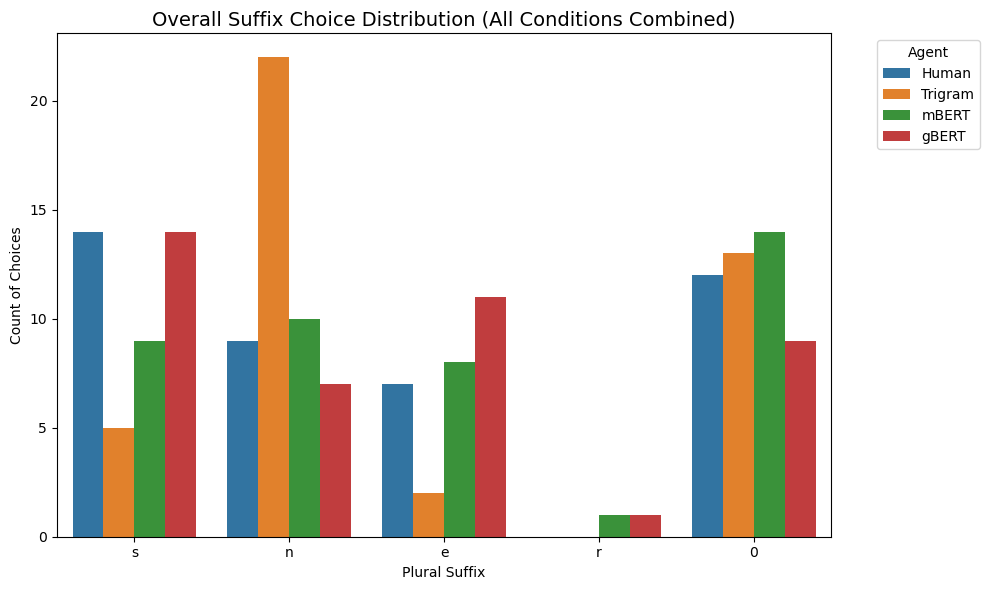

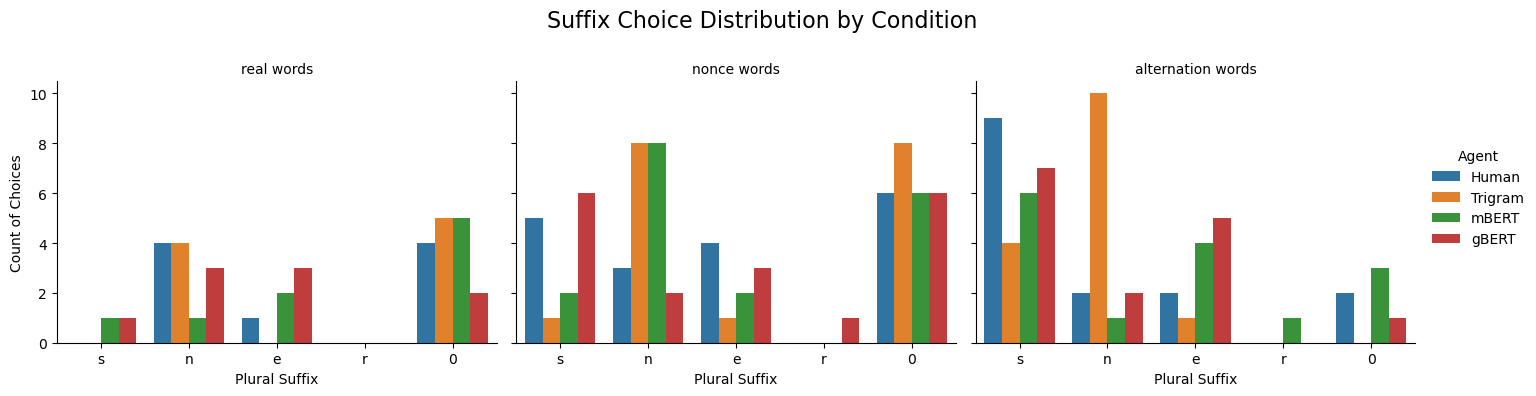

In [34]:
winner_cols = ['hum_winner', 'tri_winner', 'mbert_prediction', 'gbert_prediction', 'condition']
plot_data = analysis_df[winner_cols].melt(
    id_vars=['condition'], 
    var_name='Agent', 
    value_name='Suffix'
)
agent_map = {
    'hum_winner': 'Human',
    'tri_winner': 'Trigram',
    'mbert_prediction': 'mBERT',
    'gbert_prediction': 'gBERT'
}
plot_data['Agent'] = plot_data['Agent'].map(agent_map)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=plot_data, 
    x='Suffix', 
    hue='Agent', 
    palette='tab10', 
    order=['s', 'n', 'e', 'r', '0']
)
plt.title("Overall Suffix Choice Distribution (All Conditions Combined)", fontsize=14)
plt.ylabel("Count of Choices")
plt.xlabel("Plural Suffix")
plt.legend(title="Agent", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=plot_data, 
    x='Suffix', 
    hue='Agent', 
    col='condition', 
    kind='count',
    palette='tab10', 
    order=['s', 'n', 'e', 'r', '0'],
    col_order=['real', 'nonce', 'alternation'], # Matches your specific conditions
    height=4, 
    aspect=1.2
)
g.set_axis_labels("Plural Suffix", "Count of Choices")
g.set_titles("{col_name} words")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Suffix Choice Distribution by Condition", fontsize=16)

plt.show()

# Uncertainty

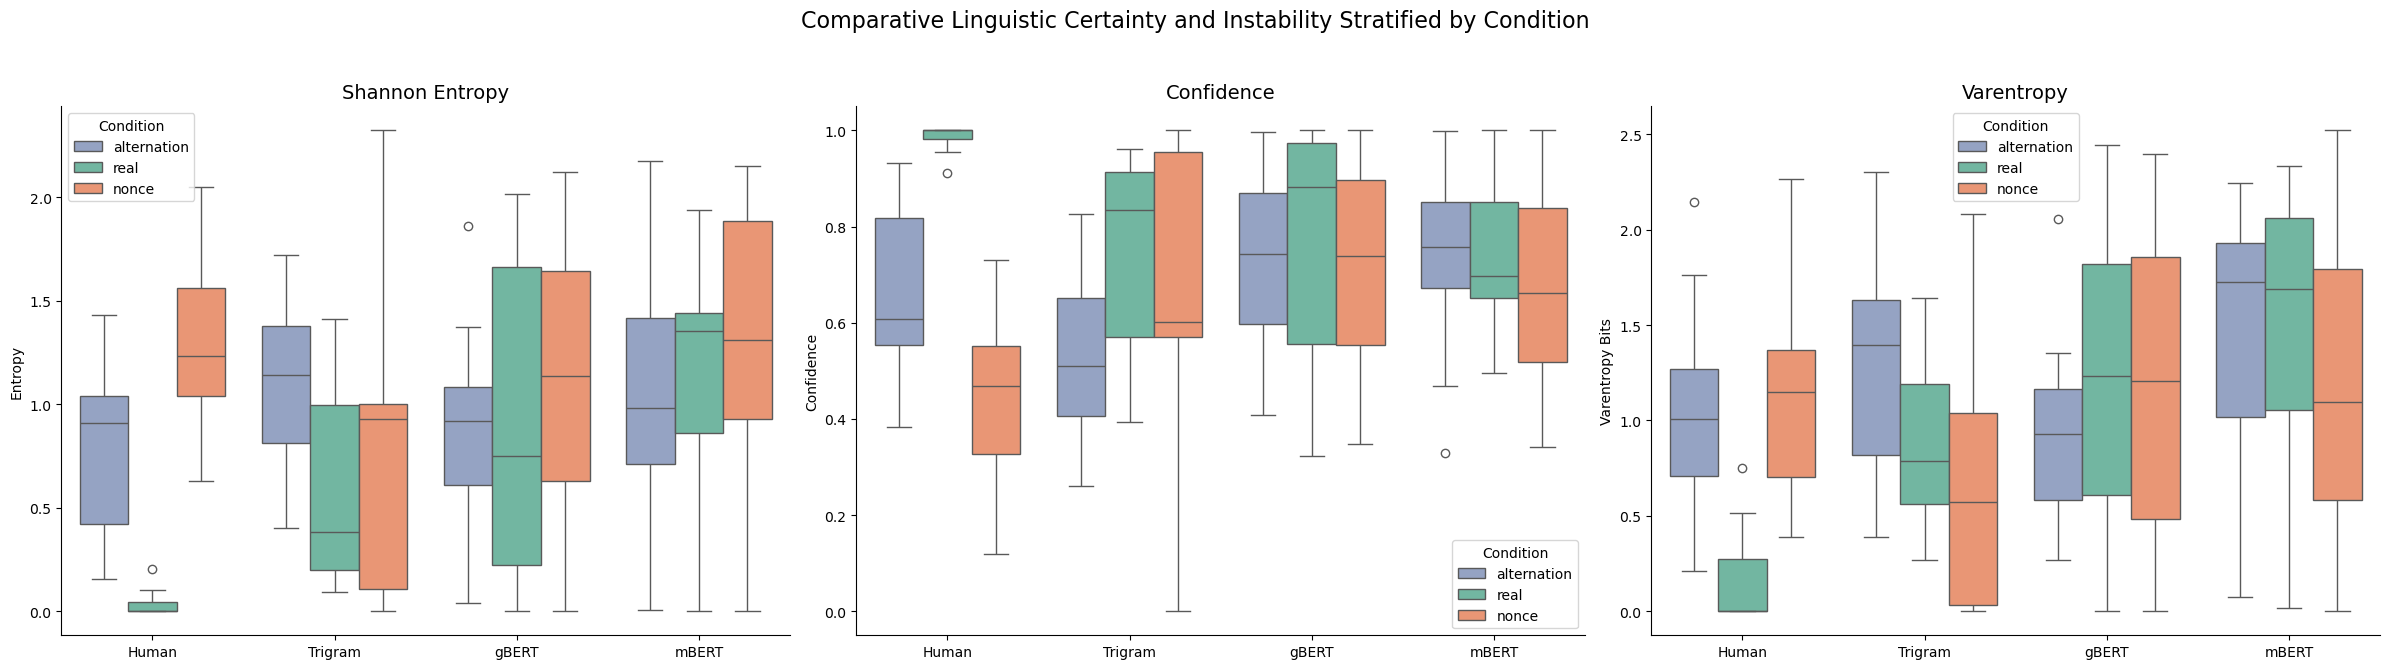

In [35]:
gender_map = {lemma: data['gender'] for lemma, data in plural_stimuli.items()}
analysis_df['gender'] = analysis_df['lemma'].map(gender_map)
analysis_df['condition'] = analysis_df['condition'].str.lower()

sources = {
    'Human': ('hum_entropy', 'hum_confidence', 'hum_varentropy'),
    'Trigram': ('tri_entropy', 'tri_confidence', 'tri_varentropy'),
    'gBERT': ('gbert_entropy', 'gbert_confidence', 'gbert_varentropy'),
    'mBERT': ('mbert_entropy', 'mbert_confidence', 'mbert_varentropy')
}

melted_list = []
for agent, (ent_col, conf_col, var_col) in sources.items():
    extract_cols = ['lemma', 'condition']
    rename_map = {'condition': 'Condition'}
    
    if ent_col in analysis_df.columns:
        extract_cols.append(ent_col)
        rename_map[ent_col] = 'Entropy'
    if conf_col in analysis_df.columns:
        extract_cols.append(conf_col)
        rename_map[conf_col] = 'Confidence'
    if var_col in analysis_df.columns:
        extract_cols.append(var_col)
        rename_map[var_col] = 'Varentropy'
        
    if len(extract_cols) > 2: # Ensure we found at least one metric for this agent
        temp = analysis_df[extract_cols].copy()
        temp = temp.rename(columns=rename_map)
        temp['Agent'] = agent
        melted_list.append(temp)

plot_df = pd.concat(melted_list, ignore_index=True)

# 3. Plotting all three subplots with Agent on the X-axis
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
palette = {
    'real': '#66c2a5', 
    'nonce': '#fc8d62', 
    'alternation': '#8da0cb' 
}
model_order = ['Human', 'Trigram', 'gBERT', 'mBERT']

# --- Subplot 1: Entropy ---
if 'Entropy' in plot_df.columns:
    sns.boxplot(ax=axes[0], data=plot_df, x='Agent', y='Entropy', hue='Condition', 
                palette=palette, order=model_order)
    axes[0].set_title('Shannon Entropy', fontsize=14)
    axes[0].set_xlabel('')

# --- Subplot 2: Confidence ---
if 'Confidence' in plot_df.columns:
    sns.boxplot(ax=axes[1], data=plot_df, x='Agent', y='Confidence', hue='Condition', 
                palette=palette, order=model_order)
    axes[1].set_title('Confidence', fontsize=14)
    axes[1].set_xlabel('')

# --- Subplot 3: Varentropy ---
if 'Varentropy' in plot_df.columns:
    sns.boxplot(ax=axes[2], data=plot_df, x='Agent', y='Varentropy', hue='Condition', 
                palette=palette, order=model_order)
    axes[2].set_title('Varentropy', fontsize=14)
    axes[2].set_xlabel('')
    axes[2].set_ylabel('Varentropy Bits')

plt.suptitle('Comparative Linguistic Certainty and Instability Stratified by Condition', fontsize=16)
sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# JSD vs humans

In [36]:
def compare_uncertainty(df, model_name):
    """Performs Wilcoxon and Pearson tests on entropy values."""
    h_hum = df['hum_entropy']
    h_mod = df[f'{model_name}_entropy']
    
    # Wilcoxon: Difference in magnitude of uncertainty
    stat, p_val = sps.wilcoxon(h_hum, h_mod)
    # Pearson: Alignment of uncertainty (confusion zones)
    corr, corr_p = sps.pearsonr(h_hum, h_mod)
    
    print(f"--- Comparison: Human vs {model_name} ---")
    print(f"Entropy Difference (Wilcoxon p-value): {p_val:.4f}")
    print(f"Confusion Correlation (Pearson r): {corr:.3f} (p={corr_p:.4f})\n")

def calculate_jsd(row, model_prefix):
    """Calculates Jensen-Shannon Divergence between human and model probability vectors."""
    # Ensure vector order is consistent: ['s', 'n', 'e', 'r', '0']
    hum_probs = [row['hum_s'], row['hum_n'], row['hum_e'], row['hum_r'], row['hum_0']]
    
    if 'bert' in model_prefix:
        mod_probs = [row[f'{model_prefix}_prob_s'], row[f'{model_prefix}_prob_n'], 
                     row[f'{model_prefix}_prob_e'], row[f'{model_prefix}_prob_r'], 
                     row[f'{model_prefix}_prob_0']]
    else:
        # Handling the Trigram/Baseline column naming convention
        mod_probs = [row['tri_s'], row['tri_n'], row['tri_e'], row['tri_r'], row['tri_0']]
        
    return jensenshannon(hum_probs, mod_probs, base=2)


# Calculate JSD scores
analysis_df['jsd_gbert'] = analysis_df.apply(lambda r: calculate_jsd(r, 'gbert'), axis=1)
analysis_df['jsd_tri'] = analysis_df.apply(lambda r: calculate_jsd(r, 'tri'), axis=1)
analysis_df['jsd_mbert'] = analysis_df.apply(lambda r: calculate_jsd(r, 'mbert'), axis=1)

print("Mean JSD by Condition (Lower is better):")
print(analysis_df.groupby('condition')[['jsd_gbert', 'jsd_tri', 'jsd_mbert']].mean())
print("-" * 30)

# Run Uncertainty Comparisons
compare_uncertainty(analysis_df, 'gbert')
compare_uncertainty(analysis_df, 'mbert')
compare_uncertainty(analysis_df, 'tri')

Mean JSD by Condition (Lower is better):
             jsd_gbert   jsd_tri  jsd_mbert
condition                                  
alternation   0.449590  0.562168   0.580348
nonce         0.596263  0.484462   0.607110
real          0.593689  0.296103   0.802768
------------------------------
--- Comparison: Human vs gbert ---
Entropy Difference (Wilcoxon p-value): 0.4275
Confusion Correlation (Pearson r): 0.030 (p=0.8510)

--- Comparison: Human vs mbert ---
Entropy Difference (Wilcoxon p-value): 0.0164
Confusion Correlation (Pearson r): 0.026 (p=0.8726)

--- Comparison: Human vs tri ---
Entropy Difference (Wilcoxon p-value): 0.9704
Confusion Correlation (Pearson r): 0.004 (p=0.9780)



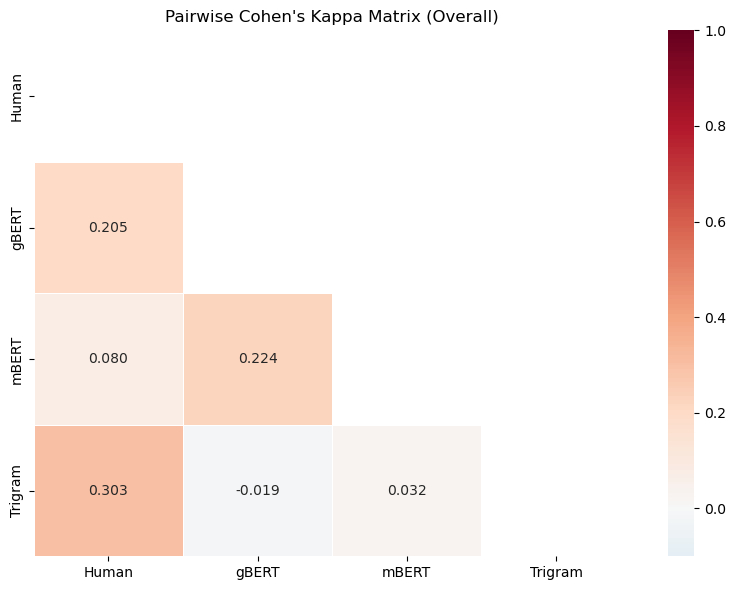

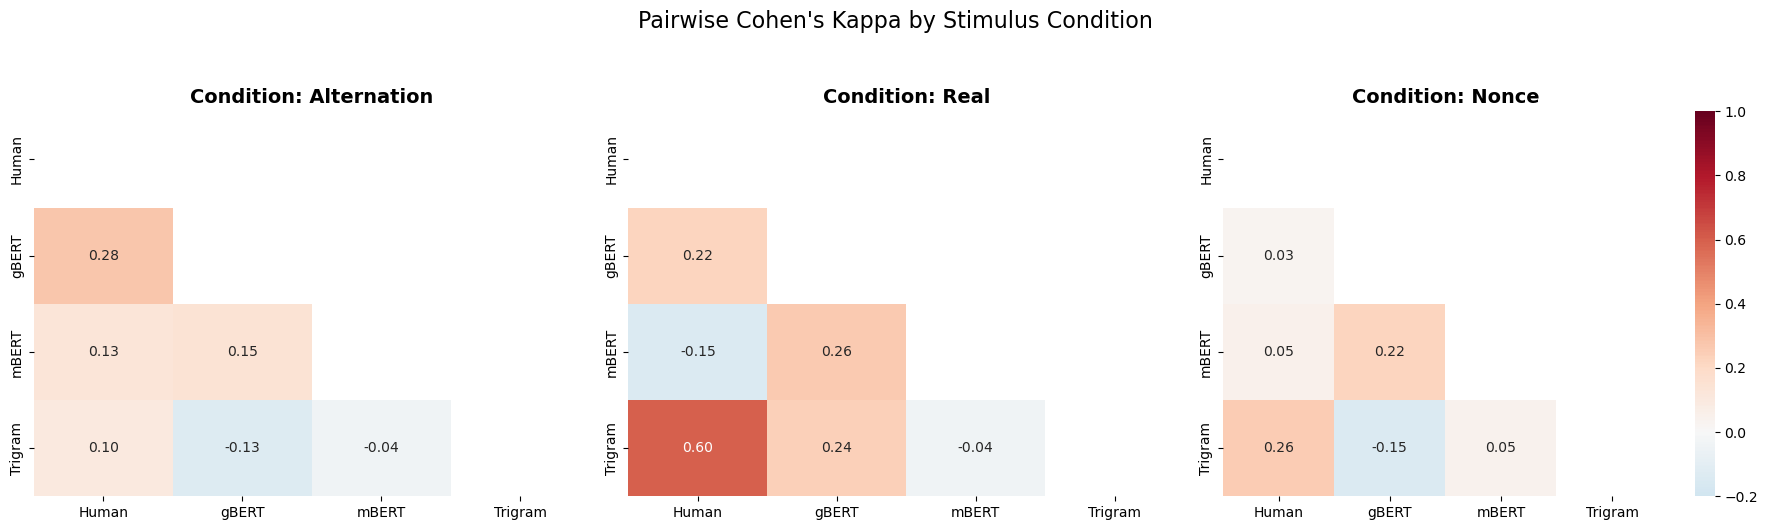

In [37]:
agents = {
    'Human': 'hum_winner',
    'gBERT': 'gbert_prediction',
    'mBERT': 'mbert_prediction',
    'Trigram': 'tri_winner'
}
conditions = analysis_df['condition'].unique()

# ==========================================
# PLOT 1: Global Pairwise Kappa Matrix
# ==========================================
kappa_matrix_global = pd.DataFrame(index=agents.keys(), columns=agents.keys(), dtype=float)

for name1, col1 in agents.items():
    for name2, col2 in agents.items():
        kappa_matrix_global.loc[name1, name2] = cohen_kappa_score(analysis_df[col1], analysis_df[col2])

mask_global = np.triu(np.ones_like(kappa_matrix_global, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    kappa_matrix_global, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-0.1, 
    vmax=1.0, 
    fmt=".3f", 
    linewidths=.5,
    mask=mask_global
)

plt.title("Pairwise Cohen's Kappa Matrix (Overall)")
plt.tight_layout()
plt.show() # <--- This now only closes the global heatmap

# ==========================================
# PLOT 2: Stratified Subplots by Condition
# ==========================================
# Create the subplots figure AFTER the first plt.show()
fig, axes = plt.subplots(1, len(conditions), figsize=(18, 5))

# Handle the edge case where there's only 1 condition (axes becomes a single object, not an array)
if len(conditions) == 1:
    axes = [axes]

for i, cond in enumerate(conditions):
    cond_df = analysis_df[analysis_df['condition'] == cond]
    
    kappa_matrix_cond = pd.DataFrame(index=agents.keys(), columns=agents.keys(), dtype=float)
    
    # Calculate pairwise Kappa
    for name1, col1 in agents.items():
        for name2, col2 in agents.items():
            try:
                kappa = cohen_kappa_score(cond_df[col1], cond_df[col2])
                kappa_matrix_cond.loc[name1, name2] = kappa
            except:
                kappa_matrix_cond.loc[name1, name2] = np.nan

    # mask 
    mask_cond = np.triu(np.ones_like(kappa_matrix_cond, dtype=bool))
    
    sns.heatmap(
        kappa_matrix_cond, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0, 
        vmin=-0.2, 
        vmax=1.0, 
        mask=mask_cond, 
        ax=axes[i],
        cbar=(i == len(conditions)-1) 
    )
    
    axes[i].set_title(f"Condition: {cond.capitalize()}", fontsize=14, fontweight='bold')

# Use fig.suptitle and fig.tight_layout to ensure it targets the correct figure
fig.suptitle("Pairwise Cohen's Kappa by Stimulus Condition", fontsize=16, y=1.05)
fig.tight_layout()
plt.show()

In [ ]:
def calculate_jsd_simple(row, model_prefix):
    hum_probs = [row['hum_s'], row['hum_n'], row['hum_e'], row['hum_r'], row['hum_0']]
    
    if 'bert' in model_prefix:
        mod_probs = [row[f'{model_prefix}_prob_s'], row[f'{model_prefix}_prob_n'], 
                     row[f'{model_prefix}_prob_e'], row[f'{model_prefix}_prob_r'], 
                     row[f'{model_prefix}_prob_0']]
    else:
        mod_probs = [row['tri_s'], row['tri_n'], row['tri_e'], row['tri_r'], row['tri_0']]
        
    return jensenshannon(hum_probs, mod_probs, base=2)

analysis_df['jsd_gbert'] = analysis_df.apply(lambda r: calculate_jsd_simple(r, 'gbert'), axis=1)
analysis_df['jsd_mbert'] = analysis_df.apply(lambda r: calculate_jsd_simple(r, 'mbert'), axis=1)
analysis_df['jsd_tri'] = analysis_df.apply(lambda r: calculate_jsd_simple(r, 'tri'), axis=1)

jsd_3model_data = analysis_df[['condition', 'jsd_gbert', 'jsd_mbert', 'jsd_tri']].melt(
    id_vars=['condition'], 
    var_name='Model', 
    value_name='JSD'
)
jsd_3model_data['Model'] = jsd_3model_data['Model'].replace({
    'jsd_gbert': 'gBERT vs Human',
    'jsd_mbert': 'mBERT vs Human',
    'jsd_tri': 'Trigram vs Human'
})

def run_jsd_stats(df, condition_name=None):
    # Filter by condition if specified, otherwise use all data
    if condition_name:
        data = df[df['condition'] == condition_name]
        print(f"=== Statistical Analysis for: {condition_name.upper()} ===")
    else:
        data = df
        print("=== Statistical Analysis for: ALL CONDITIONS ===")

    # One-Way ANOVA
    f_stat, p_val = sps.f_oneway(data['jsd_gbert'], data['jsd_mbert'], data['jsd_tri'])
    print(f"One-way ANOVA: F={f_stat:.4f}, p={p_val:.4f}")

    if p_val < 0.05:
        print("Result is SIGNIFICANT (p < 0.05). Running Post-Hoc Tukey HSD...\n")
        
        # Reshape data for Tukey (needs a 'values' column and a 'group' column)
        melted = data[['jsd_gbert', 'jsd_mbert', 'jsd_tri']].melt(var_name='Model', value_name='JSD')
        
        tukey = pairwise_tukeyhsd(endog=melted['JSD'], groups=melted['Model'], alpha=0.05)
        print(tukey)
    else:
        print("Result is NOT significant. Models perform similarly in this condition.\n")

run_jsd_stats(analysis_df, 'real')
run_jsd_stats(analysis_df, 'nonce')
run_jsd_stats(analysis_df, 'alternation')

=== Statistical Analysis for: REAL ===
One-way ANOVA: F=7.8143, p=0.0024
Result is SIGNIFICANT (p < 0.05). Running Post-Hoc Tukey HSD...

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
jsd_gbert jsd_mbert   0.2091 0.2555 -0.1126 0.5308  False
jsd_gbert   jsd_tri  -0.2976 0.0735 -0.6193 0.0241  False
jsd_mbert   jsd_tri  -0.5067 0.0017 -0.8283 -0.185   True
---------------------------------------------------------
=== Statistical Analysis for: NONCE ===
One-way ANOVA: F=1.5661, p=0.2187
Result is NOT significant. Models perform similarly in this condition.

=== Statistical Analysis for: ALTERNATION ===
One-way ANOVA: F=1.0460, p=0.3603
Result is NOT significant. Models perform similarly in this condition.



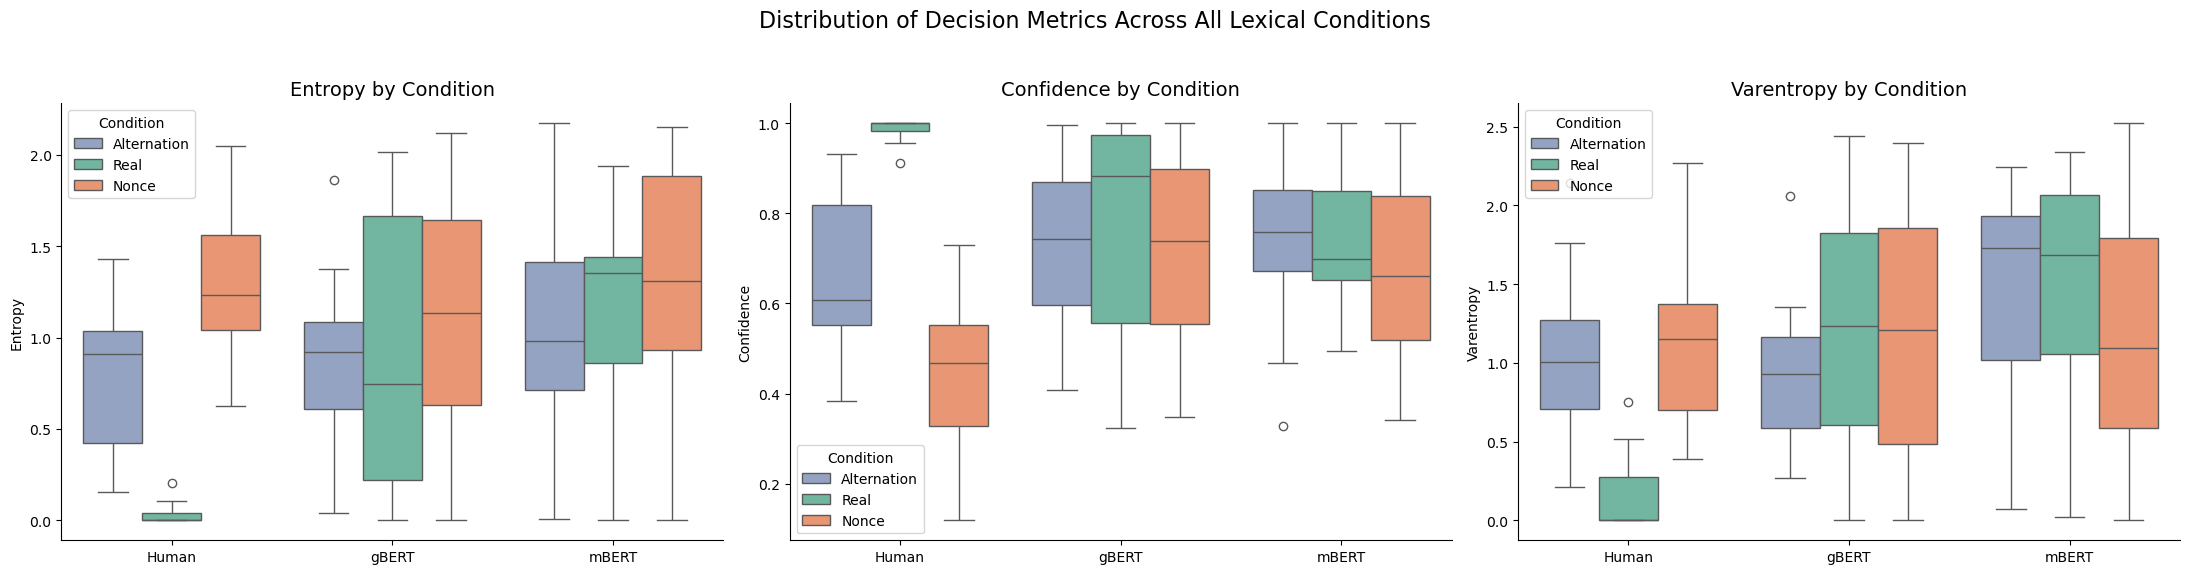

--- Kruskal-Wallis Test (Real vs. Alternation vs. Nonce) ---

Group: Human
  Entropy    | p-value: 0.0000 (significant)
  Confidence | p-value: 0.0000 (significant)
  Varentropy | p-value: 0.0002 (significant)

Group: gBERT
  Entropy    | p-value: 0.6500 (not significant)
  Confidence | p-value: 0.8265 (not significant)
  Varentropy | p-value: 0.5215 (not significant)

Group: mBERT
  Entropy    | p-value: 0.6234 (not significant)
  Confidence | p-value: 0.6985 (not significant)
  Varentropy | p-value: 0.4745 (not significant)


In [43]:
sources = {
    'Human': ('hum_entropy', 'hum_confidence', 'hum_varentropy'),
    'Trigram': ('entropy', 'confidence', 'varentropy'), 
    'gBERT': ('gbert_entropy', 'gbert_confidence', 'gbert_varentropy'),
    'mBERT': ('mbert_entropy', 'mbert_confidence', 'mbert_varentropy')
}

melted_list = []
for agent, (ent_col, conf_col, var_col) in sources.items():
    extract_cols = ['lemma', 'condition']
    rename_map = {'condition': 'Condition'}
    
    if ent_col in analysis_df.columns:
        extract_cols.append(ent_col)
        rename_map[ent_col] = 'Entropy'
    if conf_col in analysis_df.columns:
        extract_cols.append(conf_col)
        rename_map[conf_col] = 'Confidence'
    if var_col in analysis_df.columns:
        extract_cols.append(var_col)
        rename_map[var_col] = 'Varentropy'
        
    if len(extract_cols) > 2:
        temp = analysis_df[extract_cols].copy()
        temp = temp.rename(columns=rename_map)
        temp['Source'] = agent
        melted_list.append(temp)

full_comparison_df = pd.concat(melted_list, ignore_index=True)
# Standardize condition capitalization for plotting
full_comparison_df['Condition'] = full_comparison_df['Condition'].str.capitalize()

# 2. Plotting
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics = ['Entropy', 'Confidence', 'Varentropy']
palette = {'Real': '#66c2a5', 'Alternation': '#8da0cb', 'Nonce': '#fc8d62'}

for i, metric in enumerate(metrics):
    if metric in full_comparison_df.columns:
        sns.boxplot(ax=axes[i], data=full_comparison_df, x='Source', y=metric, 
                    hue='Condition', palette=palette)
        axes[i].set_title(f'{metric} by Condition', fontsize=14)
        axes[i].set_xlabel('')

plt.suptitle('Distribution of Decision Metrics Across All Lexical Conditions', fontsize=16)
sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Significance Testing (Kruskal-Wallis H-test for 3+ groups)
print("--- Kruskal-Wallis Test (Real vs. Alternation vs. Nonce) ---")
conditions = full_comparison_df['Condition'].dropna().unique()

for source in full_comparison_df['Source'].unique():
    print(f"\nGroup: {source}")
    source_df = full_comparison_df[full_comparison_df['Source'] == source]
    
    for metric in metrics:
        if metric in source_df.columns and source_df[metric].notna().any():
            # Extract groups dynamically based on available conditions
            groups = [source_df[source_df['Condition'] == cond][metric].dropna() for cond in conditions]
            
            # Only run test if we have at least 2 conditions with data
            if len([g for g in groups if len(g) > 0]) >= 2:
                stat, p = kruskal(*groups)
                sig = "significant" if p < 0.05 else "not significant"
                print(f"  {metric:10} | p-value: {p:.4f} ({sig})")
            else:
                print(f"  {metric:10} | Not enough data to test across conditions.")

# stress

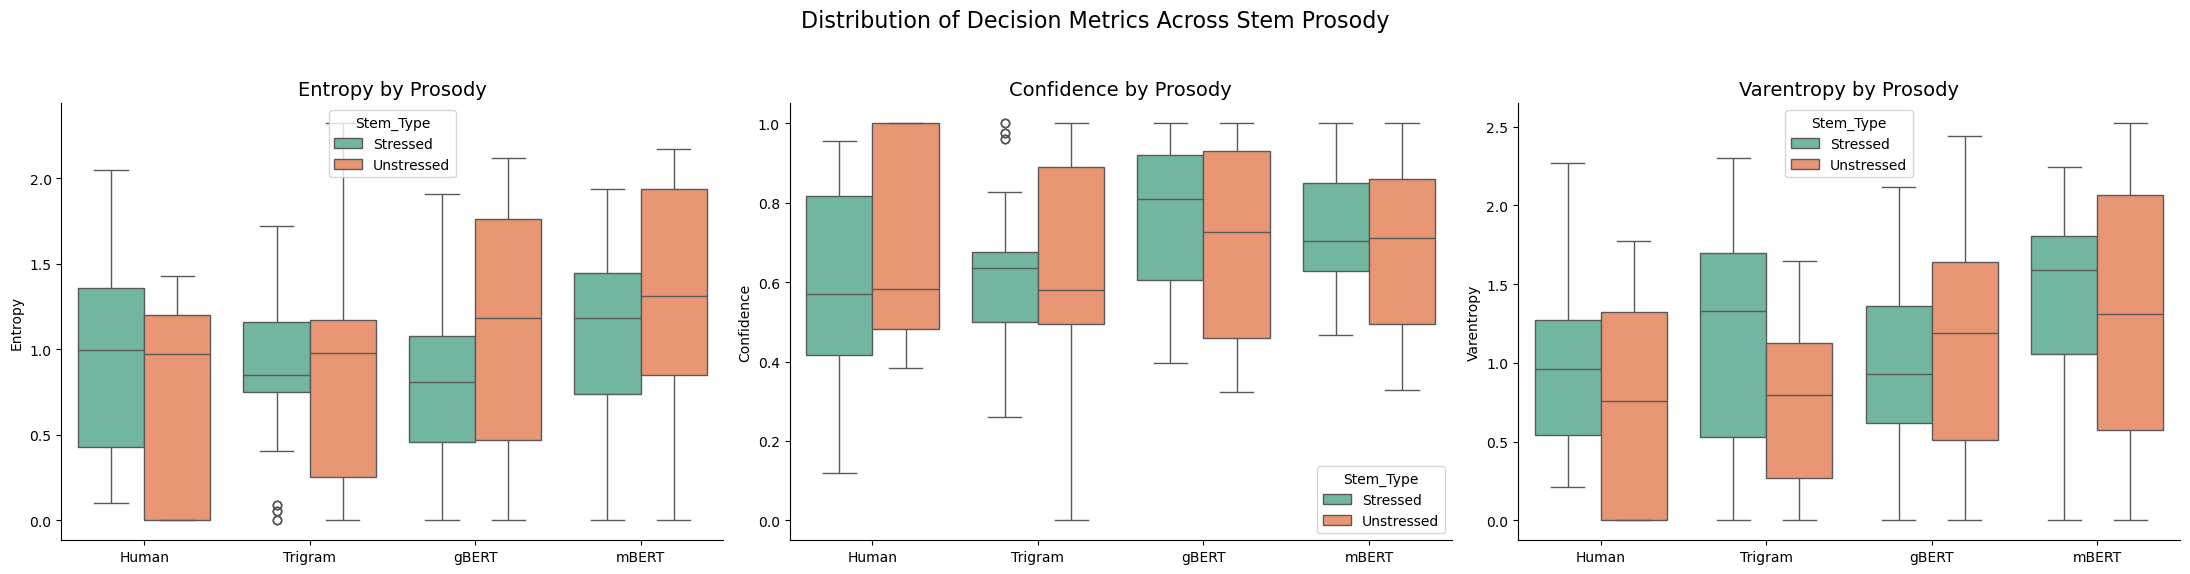

--- Mann-Whitney U Test (Stressed vs. Unstressed) ---

Group: Human
  Entropy    | p-value: 0.0431 (significant)
  Confidence | p-value: 0.0431 (significant)
  Varentropy | p-value: 0.1038 (not significant)

Group: Trigram
  Entropy    | p-value: 0.8278 (not significant)
  Confidence | p-value: 0.8278 (not significant)
  Varentropy | p-value: 0.0004 (significant)

Group: gBERT
  Entropy    | p-value: 0.0078 (significant)
  Confidence | p-value: 0.0867 (not significant)
  Varentropy | p-value: 0.4694 (not significant)

Group: mBERT
  Entropy    | p-value: 0.1043 (not significant)
  Confidence | p-value: 0.3804 (not significant)
  Varentropy | p-value: 0.8623 (not significant)


In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# 1. Map 'Stem_Type' directly onto the unified analysis_df using plural_stimuli
# Using .get() ensures it won't throw a KeyError if 'stressed_stem' is missing for a word
stress_map = {
    lemma: "Stressed" if traits.get("stressed_stem", False) else "Unstressed"
    for lemma, traits in plural_stimuli.items()
}
analysis_df['Stem_Type'] = analysis_df['lemma'].map(stress_map)

# 2. Prepare Long Format using analysis_df
sources = {
    'Human': ('hum_entropy', 'hum_confidence', 'hum_varentropy'),
    'Trigram': ('tri_entropy', 'tri_confidence', 'tri_varentropy'), 
    'gBERT': ('gbert_entropy', 'gbert_confidence', 'gbert_varentropy'),
    'mBERT': ('mbert_entropy', 'mbert_confidence', 'mbert_varentropy')
}

melted_list = []
for agent, (ent_col, conf_col, var_col) in sources.items():
    extract_cols = ['lemma', 'Stem_Type']
    rename_map = {}
    
    if ent_col in analysis_df.columns:
        extract_cols.append(ent_col)
        rename_map[ent_col] = 'Entropy'
    if conf_col in analysis_df.columns:
        extract_cols.append(conf_col)
        rename_map[conf_col] = 'Confidence'
    if var_col in analysis_df.columns:
        extract_cols.append(var_col)
        rename_map[var_col] = 'Varentropy'
        
    if len(extract_cols) > 2: # Ensure at least one metric exists for the agent
        temp = analysis_df[extract_cols].copy()
        temp = temp.rename(columns=rename_map)
        temp['Source'] = agent
        # Drop rows where Stem_Type couldn't be mapped
        temp = temp.dropna(subset=['Stem_Type'])
        melted_list.append(temp)

full_comparison_df = pd.concat(melted_list, ignore_index=True)

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics = ['Entropy', 'Confidence', 'Varentropy']
palette = {'Stressed': '#66c2a5', 'Unstressed': '#fc8d62'}

for i, metric in enumerate(metrics):
    if metric in full_comparison_df.columns:
        sns.boxplot(ax=axes[i], data=full_comparison_df, x='Source', y=metric, 
                    hue='Stem_Type', palette=palette)
        axes[i].set_title(f'{metric} by Prosody', fontsize=14)
        axes[i].set_xlabel('')

plt.suptitle('Distribution of Decision Metrics Across Stem Prosody', fontsize=16)
sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Significance Testing (Mann-Whitney U Test for 2 groups)
print("--- Mann-Whitney U Test (Stressed vs. Unstressed) ---")
for source in full_comparison_df['Source'].unique():
    print(f"\nGroup: {source}")
    source_df = full_comparison_df[full_comparison_df['Source'] == source]
    
    for metric in metrics:
        if metric in source_df.columns and source_df[metric].notna().any():
            stressed_vals = source_df[source_df['Stem_Type'] == 'Stressed'][metric].dropna()
            unstressed_vals = source_df[source_df['Stem_Type'] == 'Unstressed'][metric].dropna()
            
            if len(stressed_vals) > 0 and len(unstressed_vals) > 0:
                stat, p = mannwhitneyu(stressed_vals, unstressed_vals)
                sig = "significant" if p < 0.05 else "not significant"
                print(f"  {metric:10} | p-value: {p:.4f} ({sig})")
            else:
                print(f"  {metric:10} | Not enough data to compute.")

# Gender effects

In [ ]:
# def get_gender_analysis(lemma, gender, sentence_template, s_map, tokenizer, model):
#     # 1. Prepare inputs
#     full_prompt = sentence_template.replace("[MASK]", f"{lemma}[MASK]").replace("{gender}", gender)
#     inputs = tokenizer(full_prompt, return_tensors="pt")
#     input_ids = inputs["input_ids"][0]
    
#     # 2. Get Mask Position
#     mask_token_pos = torch.where(input_ids == tokenizer.mask_token_id)[0].item()
    
#     model.eval()
#     with torch.no_grad():
#         outputs = model(**inputs, output_attentions=True)
    
#     # 3. Extract Logits
#     logits = outputs.logits[0, mask_token_pos] 
#     target_keys = ["n", "s", "e", "r", "0"]
    
#     ids_to_pull = []
#     for k in target_keys:
#         token = s_map[k]
#         token_id = tokenizer.convert_tokens_to_ids(token) if isinstance(token, str) else int(token)
#         ids_to_pull.append(token_id)
    
#     ending_logits = torch.stack([logits[tid] for tid in ids_to_pull])
#     probs = torch.nn.functional.softmax(ending_logits, dim=-1)
    
#     # 4. Uncertainty Metrics (Calculated in PyTorch)
#     epsilon = 1e-9
    
#     # Shannon Entropy (H)
#     h_total = -torch.sum(probs * torch.log2(probs + epsilon)).item()
    
#     # Confidence (Max Probability)
#     confidence = torch.max(probs).item()
    
#     # Varentropy (Variance of surprise)
#     log_probs = torch.log2(probs + epsilon)
#     varentropy = torch.sum(probs * (log_probs + h_total)**2).item()
    
#     # 5. Attention to Gender Article
#     article_id = tokenizer.convert_tokens_to_ids(gender.lower())
#     article_indices = torch.where(input_ids == article_id)[0]
#     attn_to_gender = outputs.attentions[-1][0, :, mask_token_pos, article_indices[0]].mean().item() if len(article_indices) > 0 else 0.0

#     return {
#         "lemma": lemma,
#         "gender": gender,
#         "prediction": target_keys[torch.argmax(probs).item()],
#         "entropy": round(h_total, 4),
#         "varentropy": round(varentropy, 4),
#         "confidence": round(confidence, 4),
#         "gender_attn": round(attn_to_gender, 4)
#     }


# # 2. Run the loop
# results = []
# test_lemma = "Gupel"
# template = "Dort ist {gender} {lemma} und da sind mehrere {lemma}[MASK]."

# for g in ["der", "die", "das"]:
#     res = get_gender_analysis(test_lemma, g, template, suffix_map, gbert_tokenizer, gbert_model)
#     results.append(res)

# gender_df = pd.DataFrame(results)
# gender_df

,lemma,gender,prediction,entropy,varentropy,confidence,gender_attn
0,Gupel,der,n,1.2196,1.9471,0.7247,0.0458
1,Gupel,die,n,1.2014,1.9466,0.7284,0.0395
2,Gupel,das,n,1.3037,1.7740,0.6815,0.0360


In [70]:
# gender_analysis_df.to_csv('gender_analysis.csv')

In [45]:
gender_analysis_df=pd.read_csv('gender_analysis.csv')

In [46]:
#gender and endings

def check_gender_competition(condition):
    subset = analysis_df[analysis_df['condition'] == condition].copy()
    subset['gender'] = [plural_stimuli[k]['gender'] for k in plural_stimuli.keys() if plural_stimuli[k]['condition'] == condition]

    print(f"--- Gender vs. Suffix Choice in {condition.upper()} ---")
    for model in ['gbert_prediction', 'tri_winner', 'mbert_prediction']:
        pivot = subset.pivot_table(index='gender', columns=model, aggfunc='size', fill_value=0)
        print(f"\n{model} Pivot Table:")
        display(pivot)

check_gender_competition('alternation')

check_gender_competition('real')

check_gender_competition('nonce')

--- Gender vs. Suffix Choice in ALTERNATION ---

gbert_prediction Pivot Table:


gbert_prediction,0,e,n,s
gender,,,,
das,1,1,0,4
der,0,4,0,2
die,0,0,2,1



tri_winner Pivot Table:


tri_winner,e,n,s
gender,,,
das,1,3,2
der,0,4,2
die,0,3,0



mbert_prediction Pivot Table:


...

gbert_prediction,0,e,n,r,s
gender,,,,,
das,1,2,0,1,2
der,3,0,1,0,2
die,2,1,1,0,2



tri_winner Pivot Table:


tri_winner,0,e,n,s
gender,,,,
das,3,1,1,1
der,3,0,3,0
die,2,0,4,0



mbert_prediction Pivot Table:


mbert_prediction,0,e,n,s
gender,,,,
das,1,0,4,1
der,3,1,1,1
die,2,1,3,0


Mean Sensitivity - gBERT: 0.0386
Mean Sensitivity - mBERT: 0.0295
T-test result: t=1.106, p=0.2753


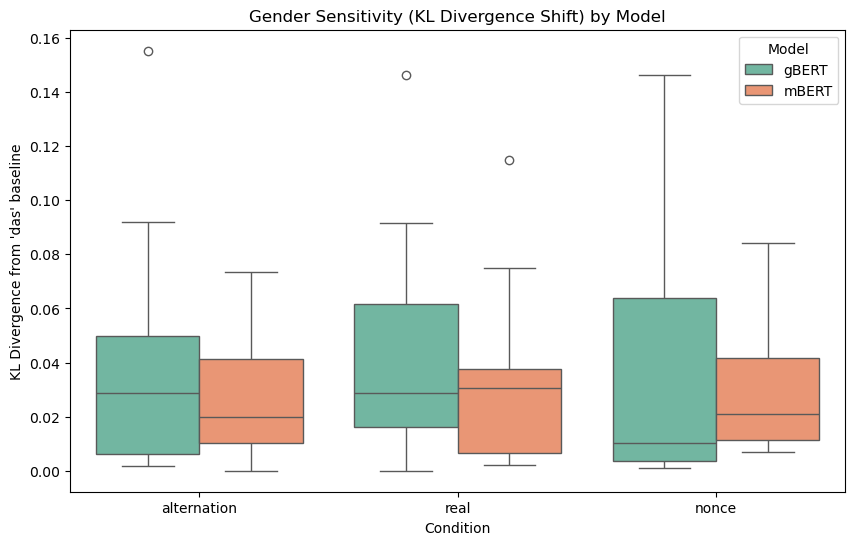

In [47]:
def calculate_kl(p_probs, q_probs):
    epsilon = 1e-9
    return torch.sum(p_probs * torch.log(p_probs / (q_probs + epsilon))).item()

def run_gender_sensitivity(model, tokenizer, suffix_map, stimuli_dict):
    kl_results = []
    template = "Dort ist {gender} {lemma} und da sind mehrere {lemma}[MASK]."
    target_keys = ["n", "s", "e", "r", "0"]
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    for lemma, info in stimuli_dict.items(): # 'lemma' is the key (e.g. "Hund")
        dist_map = {}
        
        for g in ["der", "die", "das"]:
            # Use the lemma variable directly
            prompt = template.format(gender=g, lemma=lemma)
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            mask_pos = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1].item()
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            logits = outputs.logits[0, mask_pos]
            ids = [tokenizer.convert_tokens_to_ids(suffix_map[k]) if isinstance(suffix_map[k], str) 
                   else int(suffix_map[k]) for k in target_keys]
            
            dist_map[g] = F.softmax(torch.stack([logits[tid] for tid in ids]), dim=-1)

        kl_der = calculate_kl(dist_map["das"], dist_map["der"])
        kl_die = calculate_kl(dist_map["das"], dist_map["die"])
        
        kl_results.append({
            "lemma": lemma,
            "condition": info['condition'],
            "sensitivity": (kl_der + kl_die) / 2
        })
    
    return pd.DataFrame(kl_results)

# 1. Run Analysis
gbert_kl_df = run_gender_sensitivity(gbert_model, gbert_tokenizer, suffix_map, plural_stimuli)
mbert_kl_df = run_gender_sensitivity(mbert_model, mbert_tokenizer, suffix_map, plural_stimuli)

# 2. Statistical Comparison (Paired T-test)
# Are gBERT's shifts significantly larger than mBERT's?
t_stat, p_val = sps.ttest_rel(gbert_kl_df['sensitivity'], mbert_kl_df['sensitivity'])

print(f"Mean Sensitivity - gBERT: {gbert_kl_df['sensitivity'].mean():.4f}")
print(f"Mean Sensitivity - mBERT: {mbert_kl_df['sensitivity'].mean():.4f}")
print(f"T-test result: t={t_stat:.3f}, p={p_val:.4f}")

# 3. Visualization
comparison_df = pd.DataFrame({
    'Condition': gbert_kl_df['condition'],
    'gBERT': gbert_kl_df['sensitivity'],
    'mBERT': mbert_kl_df['sensitivity']
}).melt(id_vars='Condition', var_name='Model', value_name='Sensitivity')

plt.figure(figsize=(10, 6))
sns.boxplot(data=comparison_df, x='Condition', y='Sensitivity', hue='Model', palette='Set2')
plt.title("Gender Sensitivity (KL Divergence Shift) by Model")
plt.ylabel("KL Divergence from 'das' baseline")
plt.show()

In [ ]:

sensitivity_df = gender_analysis_df.groupby('lemma').agg({
    'confidence': lambda x: x.max() - x.min(),
    'gender_attn': 'mean'
}).reset_index()

# Call pearsonr directly without the stats. prefix
correlation, p_value = pearsonr(sensitivity_df['gender_attn'], sensitivity_df['confidence'])

print(f"Correlation (Attention vs. Confidence Shift): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Correlation (Attention vs. Confidence Shift): 0.3287
P-value: 0.0618


In [52]:
def calculate_switch_rate(df):
    # Group by lemma and count unique predictions
    unique_preds = df.groupby('lemma')['prediction'].nunique()
    
    # A 'switch' occurs if there is more than 1 unique prediction for a lemma
    switches = unique_preds[unique_preds > 1]
    
    switch_count = len(switches)
    total_lemmas = len(unique_preds)
    switch_rate = (switch_count / total_lemmas) * 100
    
    return switch_rate, switches

gbert_switch_rate, gbert_switches = calculate_switch_rate(gender_analysis_df)

print(f"gBERT Gender Switch Rate: {gbert_switch_rate:.2f}%")
print(f"Total Lemmas that switched: {len(gbert_switches)}")
print("\nLemmas that changed prediction based on gender:")
print(gbert_switches)

gBERT Gender Switch Rate: 0.00%
Total Lemmas that switched: 0

Lemmas that changed prediction based on gender:
Series([], Name: prediction, dtype: int64)


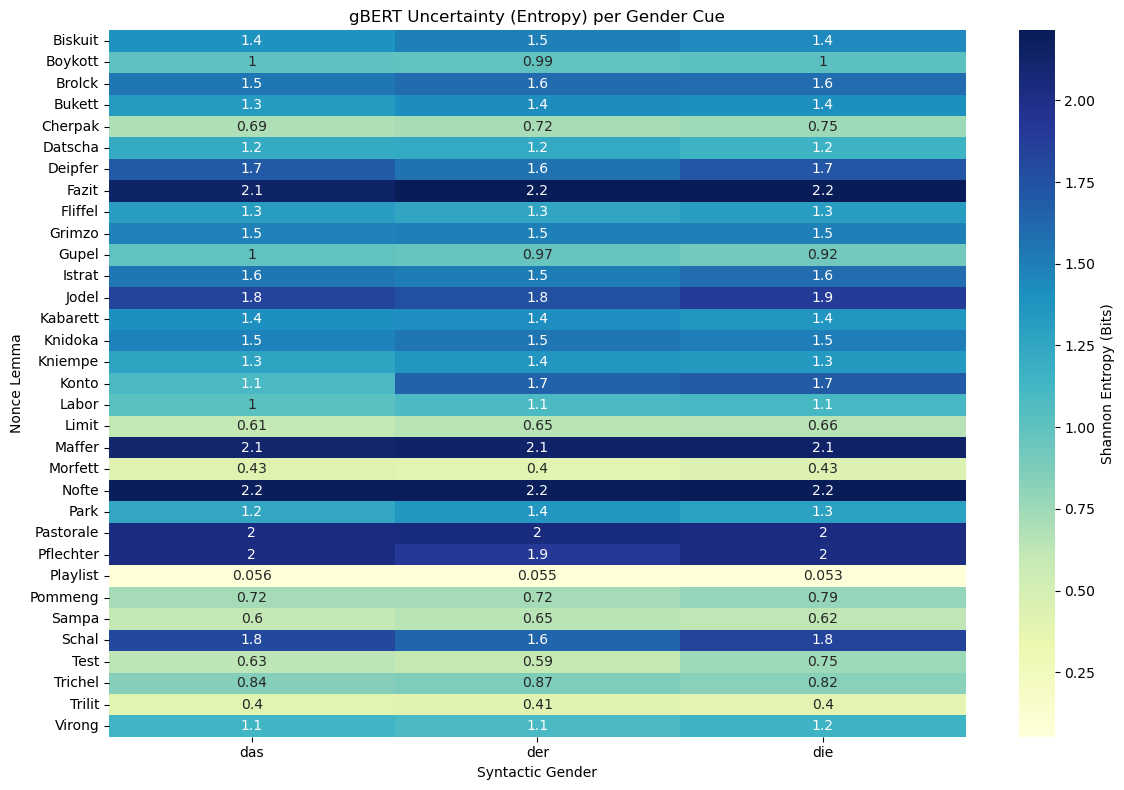

In [53]:
pivot_df = gender_analysis_df.pivot(index="lemma", columns="gender", values="entropy")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Shannon Entropy (Bits)'})
plt.title("gBERT Uncertainty (Entropy) per Gender Cue")
plt.xlabel("Syntactic Gender")
plt.ylabel("Nonce Lemma")
plt.tight_layout()
plt.show()

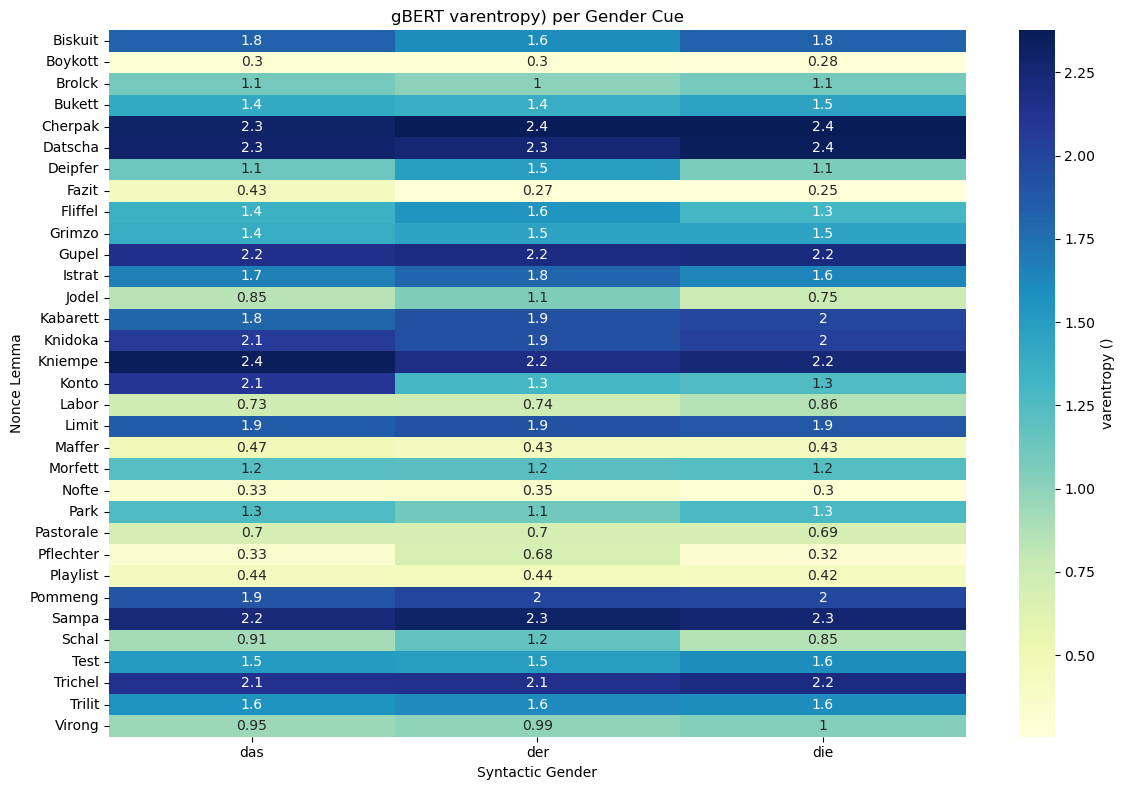

In [54]:
pivot_df = gender_analysis_df.pivot(index="lemma", columns="gender", values="varentropy")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", cbar_kws={'label': 'varentropy ()'})
plt.title("gBERT varentropy) per Gender Cue")
plt.xlabel("Syntactic Gender")
plt.ylabel("Nonce Lemma")
plt.tight_layout()
plt.show()

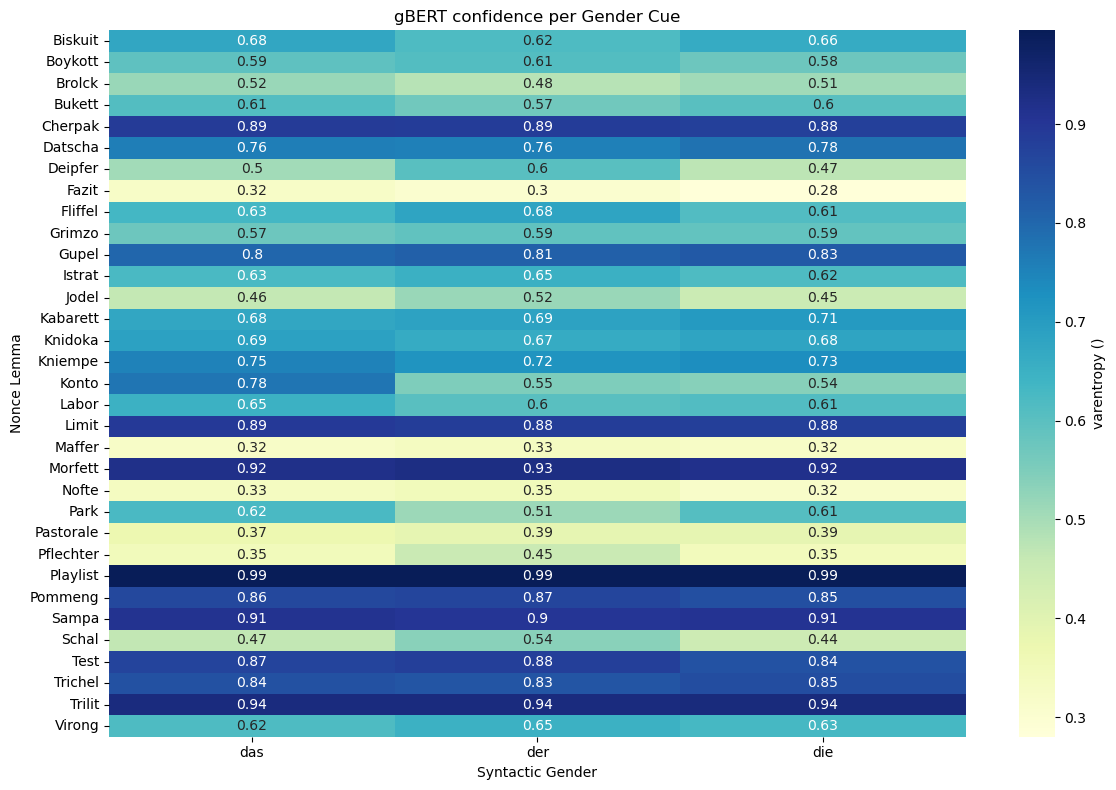

In [55]:
pivot_df = gender_analysis_df.pivot(index="lemma", columns="gender", values="confidence")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", cbar_kws={'label': 'varentropy ()'})
plt.title("gBERT confidence per Gender Cue")
plt.xlabel("Syntactic Gender")
plt.ylabel("Nonce Lemma")
plt.tight_layout()
plt.show()

In [56]:

def evaluate_models(models_dict, suffix_map, stimuli_dict):
    """
    Evaluates multiple BERT models on German pluralization metrics.
    models_dict: {'gBERT': (model, tokenizer), 'mBERT': (model, tokenizer)}
    """
    all_results = []
    template = "{gender} {lemma}, mehrere {lemma}[MASK]."
    target_keys = ["n", "s", "e", "r", "0"]
    device = "cuda" if torch.cuda.is_available() else "cpu"
    epsilon = 1e-9

    for model_name, (model, tokenizer) in models_dict.items():
        model.to(device).eval()
        
        for lemma, info in stimuli_dict.items():
            dist_map = {}
            for g in ["der", "die", "das"]:
                # Input
                prompt = template.format(gender=g, lemma=lemma)
                inputs = tokenizer(prompt, return_tensors="pt").to(device)
                mask_pos = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1].item()
                
                # Forward Pass with Attention
                with torch.no_grad():
                    outputs = model(**inputs, output_attentions=True)
                
                # Probabilities
                logits = outputs.logits[0, mask_pos]
                ids = [tokenizer.convert_tokens_to_ids(suffix_map[k]) if isinstance(suffix_map[k], str) 
                       else int(suffix_map[k]) for k in target_keys]
                probs = F.softmax(torch.stack([logits[tid] for tid in ids]), dim=-1)
                dist_map[g] = probs
                
                # Uncertainty Metrics
                h_total = -torch.sum(probs * torch.log2(probs + epsilon)).item()
                confidence = torch.max(probs).item()
                varentropy = torch.sum(probs * (torch.log2(probs + epsilon) + h_total)**2).item()
                
                # Attention to Gender Article
                article_id = tokenizer.convert_tokens_to_ids(g.lower())
                article_indices = torch.where(inputs["input_ids"] == article_id)[1]
                attn_score = outputs.attentions[-1][0, :, mask_pos, article_indices[0]].mean().item() if len(article_indices) > 0 else 0.0

                all_results.append({
                    "model": model_name,
                    "lemma": lemma,
                    "condition": info['condition'],
                    "gender_cue": g,
                    "prediction": target_keys[torch.argmax(probs).item()],
                    "confidence": confidence,
                    "entropy": h_total,
                    "varentropy": varentropy,
                    "gender_attn": attn_score
                })

    results_df = pd.DataFrame(all_results)
    return results_df


models = {
    'gBERT': (gbert_model, gbert_tokenizer),
    'mBERT': (mbert_model, mbert_tokenizer)
}

full_metrics_df = evaluate_models(models, suffix_map, plural_stimuli)

for m_name in ['gBERT', 'mBERT']:
    m_data = full_metrics_df[full_metrics_df['model'] == m_name]
    
    switches = m_data.groupby('lemma')['prediction'].nunique()
    rate = (len(switches[switches > 1]) / len(switches)) * 100
    
    sens = m_data.groupby('lemma').agg({'confidence': lambda x: x.max() - x.min(), 'gender_attn': 'mean'})
    corr, p = stats.pearsonr(sens['gender_attn'], sens['confidence'])
    
    print(f"\n[{m_name}] Summary:")
    print(f" -> Gender Switch Rate: {rate:.2f}%")
    print(f" -> Attn/Confidence Correlation: {corr:.4f} (p={p:.4f})")
    print(f" -> Mean Entropy: {m_data['entropy'].mean():.4f}")

AttributeError: 'DataFrame' object has no attribute 'pearsonr'

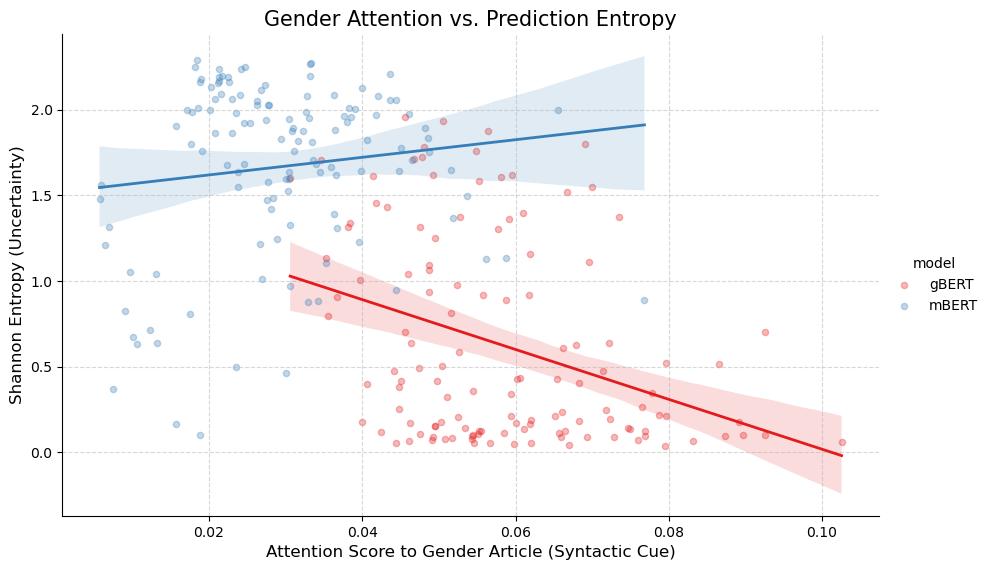

In [57]:
#gender attention
g = sns.lmplot(
    data=full_metrics_df, 
    x='gender_attn', 
    y='entropy', 
    hue='model', 
    palette='Set1',
    scatter_kws={'alpha':0.3, 's':20},
    line_kws={'linewidth': 2},
    aspect=1.5,
    height=6
)

plt.title("Gender Attention vs. Prediction Entropy", fontsize=15)
plt.xlabel("Attention Score to Gender Article (Syntactic Cue)", fontsize=12)
plt.ylabel("Shannon Entropy (Uncertainty)", fontsize=12)

plt.subplots_adjust(top=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Variance analysis

In [58]:
def quantify_variance(df, target_variable='jsd'):
    """
    Quantifies variance in a target variable (e.g., JSD or Entropy) 
    due to Gender, Trigrams, Condition, and Model.
    """
    
    formula = f"{target_variable} ~ C(gender) + C(trigram_suffix) + C(condition) + C(model)"
    
    # Ordinary Least Squares model
    model = ols(formula, data=df).fit()
    
    #Perform Type II ANOVA (unbalanced data)
    aov = sm.stats.anova_lm(model, typ=2)
    
    #Calculate Partial Eta-Squared (n2 = SS_factor / (SS_factor + SS_residual))
    aov['eta_sq'] = aov['sum_sq'] / (aov['sum_sq'] + aov.loc['Residual', 'sum_sq'])
    
    #Calculate percentage of total variance explained
    total_ss = aov['sum_sq'].sum()
    aov['perc_variance'] = (aov['sum_sq'] / total_ss) * 100
    
    return aov[['df', 'F', 'PR(>F)', 'eta_sq', 'perc_variance']]

long_df = analysis_df.melt(
    id_vars=['lemma', 'gender', 'trigram_suffix', 'condition'], 
    value_vars=['jsd_gbert', 'jsd_mbert'],
    var_name='model', value_name='jsd'
)

variance_report = quantify_variance(long_df, target_variable='jsd')
print("Variance Breakdown for JSD (Human-Likeness):")
print(variance_report.sort_values(by='perc_variance', ascending=False))

Variance Breakdown for JSD (Human-Likeness):
                     df         F    PR(>F)    eta_sq  perc_variance
C(trigram_suffix)  37.0  3.079212  0.000266  0.730650      63.329995
Residual           42.0       NaN       NaN  0.500000      23.346264
C(gender)           2.0  4.666792  0.014784  0.181822       5.188197
C(condition)        2.0  4.355028  0.019110  0.171762       4.841601
C(model)            1.0  5.925813  0.019252  0.123646       3.293943


In [59]:

# 1. Construct Probability Distributions
# We define the fixed order of suffixes: [n, s, e, r, 0]
suffix_order = ['n', 's', 'e', 'r', '0']

def make_dist(row, prefix):
    # This gathers counts/probs for each suffix into a single vector
    # Adjust 'prefix' to match your column names (e.g., 'hum_n', 'gbert_prob_n')
    dist = [row.get(f"{prefix}_{s}", 0) for s in suffix_order]
    # Normalize to ensure it sums to 1
    total = sum(dist)
    return [x/total for x in dist] if total > 0 else [0] * len(suffix_order)

# Create the missing distribution columns
# (Ensure these prefixes match your actual column names for counts/probs)
analysis_df['hum_dist'] = analysis_df.apply(lambda x: make_dist(x, 'hum'), axis=1)
analysis_df['gbert_dist'] = analysis_df.apply(lambda x: make_dist(x, 'gbert'), axis=1)
analysis_df['mbert_dist'] = analysis_df.apply(lambda x: make_dist(x, 'mbert'), axis=1)

# 2. Calculate JSD
def calculate_jsd(row, model_prefix):
    p = row['hum_dist']
    q = row[f'{model_prefix}_dist']
    # If a distribution is all zeros, return max divergence (1.0)
    if sum(p) == 0 or sum(q) == 0: return 1.0
    return jensenshannon(p, q, base=2)**2

analysis_df['jsd_gbert'] = analysis_df.apply(lambda x: calculate_jsd(x, 'gbert'), axis=1)
analysis_df['jsd_mbert'] = analysis_df.apply(lambda x: calculate_jsd(x, 'mbert'), axis=1)

# 3. Reshape for ANOVA
long_df = analysis_df.melt(
    id_vars=['lemma', 'gender', 'trigram_suffix', 'condition'], 
    value_vars=['jsd_gbert', 'jsd_mbert'],
    var_name='model', value_name='jsd'
)
long_df['model'] = long_df['model'].str.replace('jsd_', '')

# 4. Multifactorial ANOVA with Interaction (Gender * Model)
formula = "jsd ~ C(gender) * C(model) + C(trigram_suffix) + C(condition)"
model_fit = ols(formula, data=long_df).fit()
aov = sm.stats.anova_lm(model_fit, typ=2)

# Calculate Variance metrics
aov['eta_sq'] = aov['sum_sq'] / (aov['sum_sq'] + aov.loc['Residual', 'sum_sq'])
aov['perc_variance'] = (aov['sum_sq'] / aov['sum_sq'].sum()) * 100

aov.sort_values(by='perc_variance', ascending=False)

,sum_sq,df,F,PR(>F),eta_sq,perc_variance
Residual,2.706779e-29,40.0,NaN,NaN,0.500000,63.697451
C(trigram_suffix),1.303853e-29,37.0,0.520756,0.976146,0.325099,30.683012
C(gender),8.837742e-31,2.0,0.653008,0.525937,0.031618,2.079747
C(gender):C(model),8.461367e-31,2.0,0.625198,0.540303,0.030312,1.991177
C(model),5.893552e-31,1.0,0.870932,0.356297,0.021309,1.386904
C(condition),6.871718e-32,2.0,0.050774,0.950554,0.002532,0.161709


In [61]:


# 1. Calculate Human Entropy
# We calculate the Shannon entropy of the human probability distribution
def calc_entropy(dist):
    # Filter out zeros to avoid log(0) warnings
    clean_dist = [p for p in dist if p > 0]
    return entropy(clean_dist, base=2) if clean_dist else 0.0

analysis_df['hum_entropy'] = analysis_df['hum_dist'].apply(calc_entropy)

# 2. Prepare Human-Only Dataframe
# We only need one row per lemma, so we drop the model duplicates
human_df = analysis_df[['lemma', 'gender', 'trigram_suffix', 'condition', 'hum_entropy']].drop_duplicates()

# Explicitly cast categorical columns
categorical_cols = ['gender', 'trigram_suffix', 'condition']
for col in categorical_cols:
    human_df[col] = human_df[col].astype('category')

# Drop NaNs
human_df = human_df.dropna(subset=categorical_cols + ['hum_entropy'])

# 3. Run the ANOVA
formula = "hum_entropy ~ C(gender) + C(trigram_suffix) + C(condition)"

human_model_fit = ols(formula, data=human_df).fit()

human_aov = sm.stats.anova_lm(human_model_fit, typ=2)

# 4. Calculate Variance Breakdown
human_aov['eta_sq'] = human_aov['sum_sq'] / (human_aov['sum_sq'] + human_aov.loc['Residual', 'sum_sq'])
human_aov['perc_variance'] = (human_aov['sum_sq'] / human_aov['sum_sq'].sum()) * 100

print("\n--- Human Variance Analysis (Entropy) ---")
human_aov.sort_values(by='perc_variance', ascending=False)


--- Human Variance Analysis (Entropy) ---


,sum_sq,df,F,PR(>F),eta_sq,perc_variance
C(trigram_suffix),4.412461,37.0,34.430393,0.134394,0.999216,82.071163
C(condition),0.749455,2.0,108.187891,0.067826,0.995400,13.939768
C(gender),0.211004,2.0,30.459554,0.127083,0.983850,3.924645
Residual,0.003464,1.0,NaN,NaN,0.500000,0.064424


# Single words

In [74]:
import pandas as pd
import numpy as np

# 1. Safely map metadata directly from plural_stimuli
# The .get() method ensures that if a lemma or key is missing, it won't crash.
analysis_df['token_count'] = analysis_df['lemma'].map(lambda x: plural_stimuli.get(x, {}).get('token_count', 1))
analysis_df['trigram_suffix'] = analysis_df['lemma'].map(lambda x: plural_stimuli.get(x, {}).get('trigram_suffix', ''))
analysis_df['neighbor_dist'] = analysis_df['lemma'].map(lambda x: plural_stimuli.get(x, {}).get('neighbor_dist', np.nan))

# 2. Add gBERT metrics if missing
if 'confidence' not in analysis_df.columns:
    gbert_metrics = full_metrics_df[full_metrics_df['model'] == 'gBERT'][['lemma', 'confidence', 'entropy']]
    analysis_df = analysis_df.merge(gbert_metrics, on='lemma', how='left')

# 3. Disagreement Function
def find_disagreements(df):
    # tri_winner represents the "Frequency Winner" (the typical behavior)
    # gbert_prediction represents the "Neural Winner"
    disagreements = df[df['gbert_prediction'] != df['tri_winner']].copy()
    
    # token_count is now guaranteed to exist
    disagreements['is_split'] = disagreements['token_count'] > 1
    
    # Check which columns are actually available to show
    target_cols = ['lemma', 'trigram_suffix', 'tri_winner', 'gbert_prediction', 
                   'confidence', 'entropy', 'is_split', 'neighbor_dist']
    cols_to_show = [col for col in target_cols if col in disagreements.columns]
    
    return disagreements[cols_to_show].sort_values(by='confidence', ascending=False)

# 4. Execute and display
gbert_vs_tri = find_disagreements(analysis_df)

print(f"Total Disagreements: {len(gbert_vs_tri)} out of {len(analysis_df)}")
print("\nTop 10 High-Confidence Disagreements (Neural Overrides):")
print(gbert_vs_tri.head(10).to_string(index=False))

Total Disagreements: 102 out of 126

Top 10 High-Confidence Disagreements (Neural Overrides):
      lemma trigram_suffix tri_winner gbert_prediction  confidence  entropy  is_split  neighbor_dist
     Kissen                         0                e    0.996621 0.037867     False            NaN
    Kniempe                         n                0    0.996102 0.044047     False            NaN
     Kissen                         0                e    0.995915 0.044980     False            NaN
    Kniempe                         n                0    0.995325 0.051519     False            NaN
    Fliffel                         0                s    0.995223 0.052507     False            NaN
    Trichel                         n                0    0.995123 0.053016     False            NaN
    Trichel                         n                0    0.994796 0.055785     False            NaN
     Kissen                         0                e    0.993873 0.064067     False            N

In [75]:
print("\nSuffix Distribution in Nonce Condition:")
for agent in ['hum_winner', 'gbert_prediction', 'mbert_prediction', 'tri_winner']:
    counts = nonce_df[agent].value_counts(normalize=True).mul(100).round(1)
    print(f"{agent.split('_')[0].upper()} Suffix Choice (%):")
    print(counts.to_dict())


Suffix Distribution in Nonce Condition:
HUM Suffix Choice (%):
{'0': 33.3, 's': 27.8, 'e': 22.2, 'n': 16.7}
GBERT Suffix Choice (%):
{'s': 33.3, '0': 33.3, 'e': 16.7, 'n': 11.1, 'r': 5.6}
MBERT Suffix Choice (%):
{'n': 44.4, '0': 33.3, 'e': 11.1, 's': 11.1}
TRI Suffix Choice (%):
{'n': 44.4, '0': 44.4, 'e': 5.6, 's': 5.6}


In [76]:
nonce_df = analysis_df[analysis_df['condition'] == 'nonce'].copy()

def get_jsd(row, prefix):
    h = [row['hum_s'], row['hum_n'], row['hum_e'], row['hum_r'], row['hum_0']]
    m = [row[f'{prefix}_prob_s'], row[f'{prefix}_prob_n'], 
         row[f'{prefix}_prob_e'], row[f'{prefix}_prob_r'], 
         row[f'{prefix}_prob_0']]
    return jensenshannon(h, m, base=2)

nonce_df['jsd_mbert'] = nonce_df.apply(lambda r: get_jsd(r, 'mbert'), axis=1)

# 2. Identify the "Conflict Cases" (Top 10 outliers for gBERT)
conflicts = nonce_df.sort_values(by='jsd_gbert', ascending=False).head(10)

# 3. Create a clean comparison table for these words
outlier_report = conflicts[[
    'lemma', 'trigram_suffix', 'hum_winner', 
    'gbert_prediction', 'mbert_prediction', 'tri_winner',
    'jsd_gbert', 'jsd_mbert'
]]

print("Top 10 Nonce Divergence Cases (Humans vs. Models):")
print(outlier_report.to_string(index=False))

Top 10 Nonce Divergence Cases (Humans vs. Models):
  lemma trigram_suffix hum_winner gbert_prediction mbert_prediction tri_winner  jsd_gbert  jsd_mbert
  Gupel                         0                n                n          n        1.0   0.540812
  Gupel                         0                n                n          n        1.0   0.540812
  Gupel                         0                n                n          n        1.0   0.540812
 Maffer                         0                s                n          0        1.0   0.781659
 Maffer                         0                s                n          0        1.0   0.781659
 Maffer                         0                s                n          0        1.0   0.781659
Morfett                         e                0                0          n        1.0   0.946761
Morfett                         e                0                0          n        1.0   0.946761
Morfett                         e       

In [64]:
nonce_conflicts = analysis_df[analysis_df['condition'] == 'nonce'].sort_values(by='jsd_gbert', ascending=False)

outlier_report = nonce_conflicts[[
    'lemma', 'hum_winner', 'gbert_prediction', 'jsd_gbert', 
    'hum_entropy', 'gbert_entropy', 'trigram_suffix'
]].head(10)

print("Top 10 Nonce Words where Humans and gBERT Diverge Most:")
display(outlier_report)

gbert_n_count = (nonce_conflicts['gbert_prediction'] == 'n').sum()
human_s_count = (nonce_conflicts['hum_winner'] == 's').sum()

print(f"\nIn Nonce Condition:")
print(f"Total instances where gBERT chose '-n': {gbert_n_count}")
print(f"Total instances where Humans chose '-s': {human_s_count}")

Top 10 Nonce Words where Humans and gBERT Diverge Most:


,lemma,hum_winner,gbert_prediction,jsd_gbert,hum_entropy,gbert_entropy,trigram_suffix
72,Gupel,0,n,1.0,1.402889,0.9247,pel
73,Gupel,0,n,1.0,1.402889,0.9247,pel
74,Gupel,0,n,1.0,1.402889,0.9247,pel
75,Maffer,0,s,1.0,0.904129,1.7642,fer
76,Maffer,0,s,1.0,0.904129,1.7642,fer
77,Maffer,0,s,1.0,0.904129,1.7642,fer
78,Morfett,e,0,1.0,1.725813,0.0000,ett
79,Morfett,e,0,1.0,1.725813,0.0000,ett
80,Morfett,e,0,1.0,1.725813,0.0000,ett
81,Trilit,s,e,1.0,1.612857,1.5743,lit



In Nonce Condition:
Total instances where gBERT chose '-n': 6
Total instances where Humans chose '-s': 15


In [79]:
import torch
import torch.nn.functional as F

def get_bert_embedding(word, model, tokenizer):
    """
    Extracts the mean-pooled embedding for a word, ignoring special tokens.
    """
    # Tokenize and move to the appropriate device
    inputs = tokenizer(word, return_tensors="pt")
    
    with torch.no_grad():
        # Get hidden states from the base model
        outputs = model.bert(**inputs) if hasattr(model, 'bert') else model(**inputs)
        
    hidden_states = outputs.last_hidden_state
    
    # Exclude [CLS] (index 0) and [SEP] (last index), then mean-pool the sub-tokens
    word_embedding = hidden_states[0, 1:-1, :].mean(dim=0)
    
    # Reshape to (1, hidden_size) for cosine_similarity
    return word_embedding.unsqueeze(0)

def get_nearest_real_neighbor(nonce_lemma, real_lemmas, model, tokenizer):
    """
    Finds the specific real word that is closest to the nonce word in BERT space.
    """
    nonce_vec = get_bert_embedding(nonce_lemma, model, tokenizer)
    
    best_sim = -1
    neighbor = None
    
    for real in real_lemmas:
        real_vec = get_bert_embedding(real, model, tokenizer)
        sim = F.cosine_similarity(nonce_vec, real_vec).item()
        if sim > best_sim:
            best_sim = sim
            neighbor = real
            
    return neighbor, best_sim

# Extract unique real words from your dataset
real_lemmas = analysis_df[analysis_df['condition'].isin(['real', 'alternation'])]['lemma'].unique().tolist()

# Test on the top disagreement
if not gbert_vs_tri.empty:
    target_lemma = gbert_vs_tri.iloc[0]['lemma']
    neighbor, similarity = get_nearest_real_neighbor(target_lemma, real_lemmas, gbert_model, gbert_tokenizer)
    
    print(f"\n--- Deep Dive: {target_lemma} ---")
    print(f"Trigram Prediction: {gbert_vs_tri.iloc[0]['tri_winner']}")
    print(f"gBERT Prediction:   {gbert_vs_tri.iloc[0]['gbert_prediction']}")
    print(f"Nearest Real Word:  {neighbor} (Similarity: {similarity:.4f})")


--- Deep Dive: Kissen ---
Trigram Prediction: 0
gBERT Prediction:   e
Nearest Real Word:  Kissen (Similarity: 1.0000)


In [82]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

def get_global_nearest_noun(nonce_lemma, model, tokenizer, top_k=1):
    """
    Finds the closest capitalized whole word (noun heuristic) in the entire BERT vocabulary.
    """
    # 1. Get the pooled embedding for the nonce word
    nonce_vec = get_bert_embedding(nonce_lemma, model, tokenizer) # Shape: [1, hidden_size]
    
    # 2. Extract the entire vocabulary embedding matrix
    all_embeddings = model.get_input_embeddings().weight # Shape: [vocab_size, hidden_size]
    
    # 3. Compute cosine similarity against all tokens simultaneously
    with torch.no_grad():
        cos_similarities = F.cosine_similarity(nonce_vec, all_embeddings)
        
    # 4. Get the top N closest tokens (pulling extra to account for filtering)
    top_scores, top_indices = torch.topk(cos_similarities, k=100)
    
    # 5. Filter the results to find the first valid noun
    inv_vocab = {v: k for k, v in tokenizer.get_vocab().items()}
    
    valid_neighbors = []
    for score, idx in zip(top_scores, top_indices):
        token = inv_vocab[idx.item()]
        
        # FILTER: Must be alphabetic, not a sub-word, and must be Capitalized (German noun)
        if not token.startswith("##") and not token.startswith("[") and token.isalpha():
            if token.istitle(): # <--- This ensures it's a noun
                # Exclude the word itself if it happens to be in the vocab
                if token.lower() != nonce_lemma.lower():
                    valid_neighbors.append((token, score.item()))
                    if len(valid_neighbors) == top_k:
                        break
                    
    if valid_neighbors:
        return valid_neighbors[0][0], valid_neighbors[0][1]
    else:
        return None, np.nan

# Execute on your disagreements dataframe
print("Scanning entire BERT vocabulary for global noun attractors...\n")
global_neighbors = []
global_similarities = []

for lemma in tqdm(gbert_vs_tri['lemma'], desc="Global Search"):
    neighbor, sim = get_global_nearest_noun(lemma, gbert_model, gbert_tokenizer)
    global_neighbors.append(neighbor)
    global_similarities.append(sim)

gbert_vs_tri['global_noun_attractor'] = global_neighbors
gbert_vs_tri['global_noun_sim'] = global_similarities

cols_to_print = ['lemma', 'tri_winner', 'gbert_prediction', 'global_noun_attractor', 'global_noun_sim', 'is_split']
print("\nTop Global Neural Overrides and their Lexical Noun Attractors:")
print(gbert_vs_tri[cols_to_print].head(15).to_string(index=False))

Scanning entire BERT vocabulary for global noun attractors...



Global Search:   0%|          | 0/102 [00:00<?, ?it/s]

Global Search: 100%|██████████| 102/102 [03:16<00:00,  1.92s/it]



Top Global Neural Overrides and their Lexical Noun Attractors:
      lemma tri_winner gbert_prediction global_noun_attractor  global_noun_sim  is_split
     Kissen          0                e                  Kiss         0.113200     False
    Kniempe          n                0                  Knie         0.118322     False
     Kissen          0                e                  Kiss         0.113200     False
    Kniempe          n                0                  Knie         0.118322     False
    Fliffel          0                s                   Der         0.113032     False
    Trichel          n                0                   Der         0.106874     False
    Trichel          n                0                   Der         0.106874     False
     Kissen          0                e                  Kiss         0.113200     False
    Fliffel          0                s                   Der         0.113032     False
Freizeichen          0                s       

In [ ]:
# analysis_df.to_csv('./results/all_results.csv')

# Attention maps clozes

In [ ]:
def plot_tokenized_sentence_attention(lemma, sentence_template, model=gbert_model, tokenizer=gbert_tokenizer):
   
    probing_sentence = sentence_template.replace("[MASK]", f"{lemma}[MASK]")
    inputs = tokenizer(probing_sentence, return_tensors="pt")
    all_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    mask_idx = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1].item()

    with torch.no_grad():
        outputs = model(**inputs)

    mask_attention = outputs.attentions[-1][0, :, mask_idx, :].mean(dim=0).tolist()
    
    plt.figure(figsize=(14, 2.5))
    sns.heatmap([mask_attention], 
                annot=True, 
                fmt=".3f", 
                xticklabels=all_tokens, 
                cmap="YlGnBu", 
                cbar=False, 
                annot_kws={"size": 9})
    
    plt.title(f"Attention Weights for [MASK] in: {lemma}", fontsize=12, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

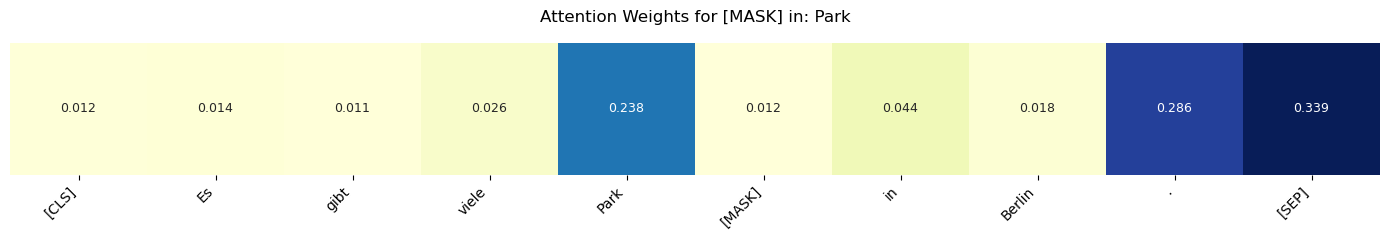

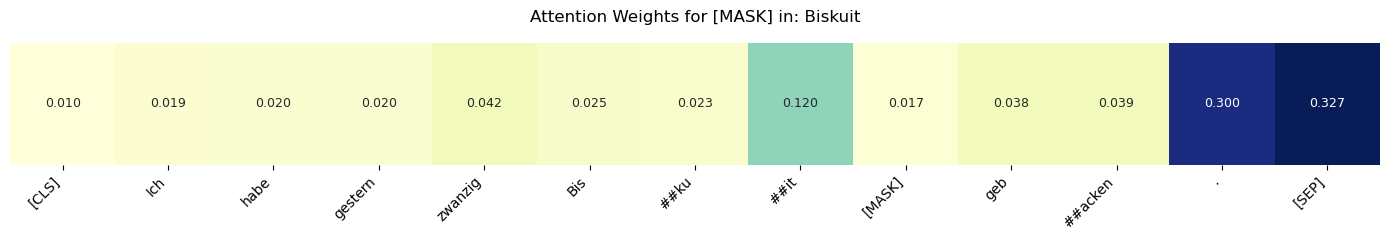

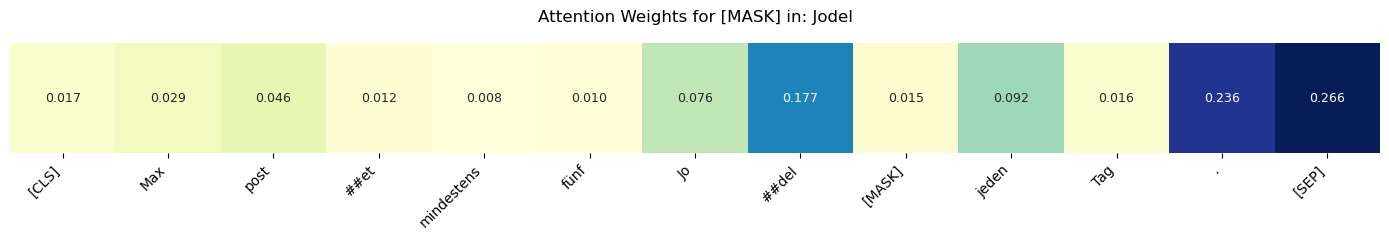

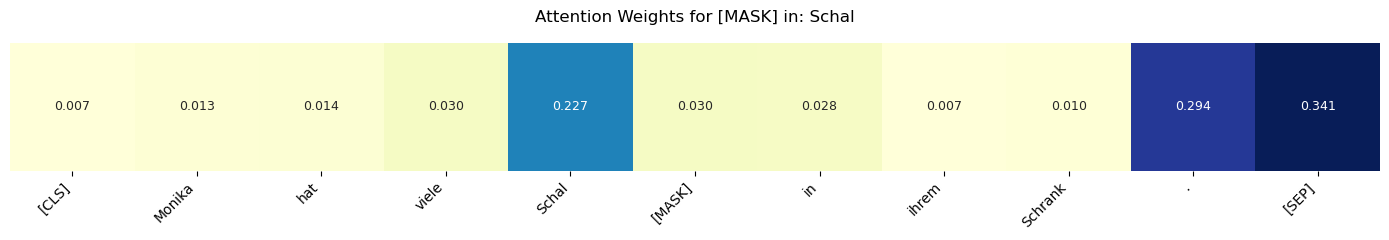

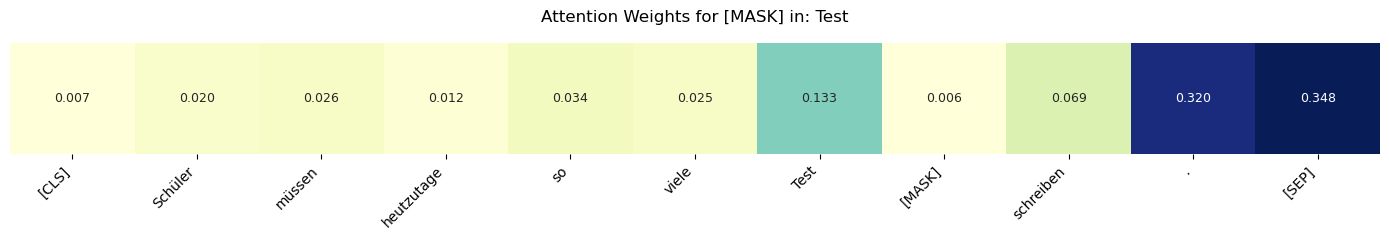

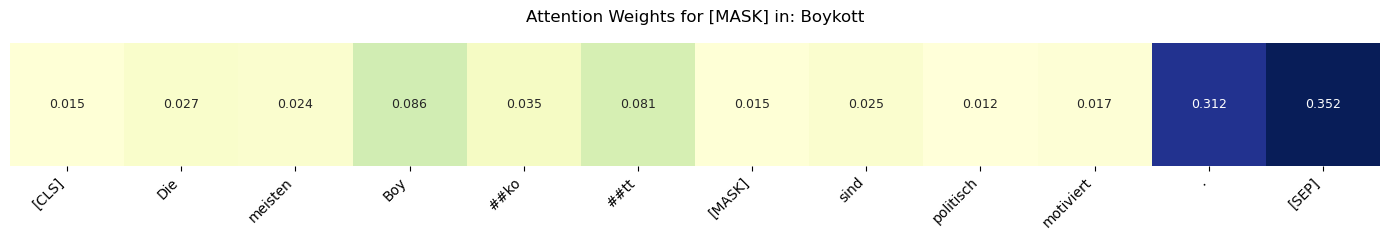

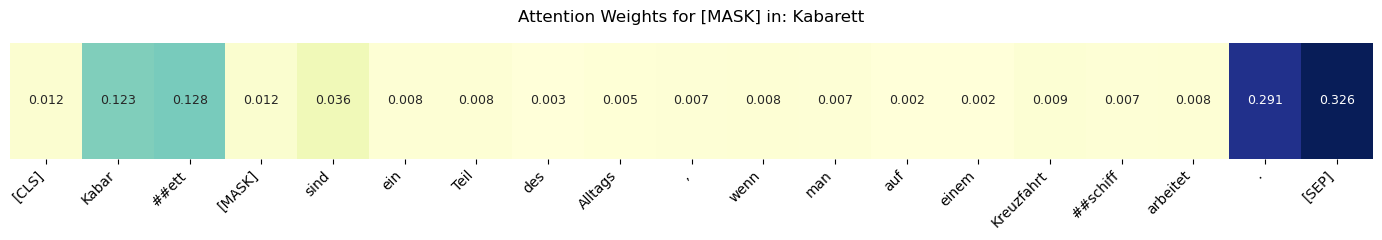

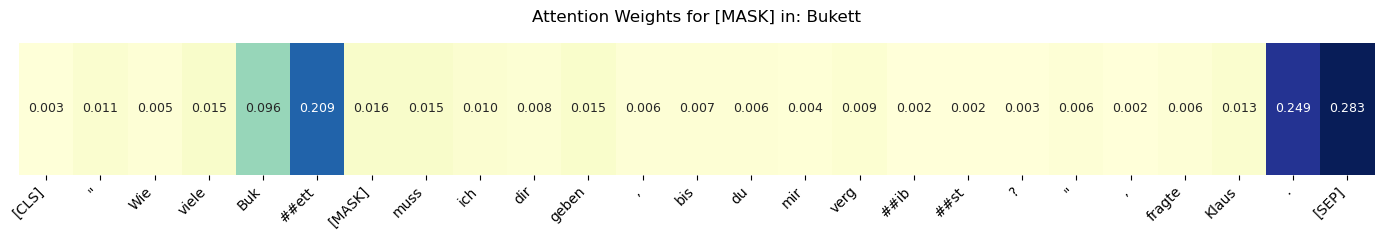

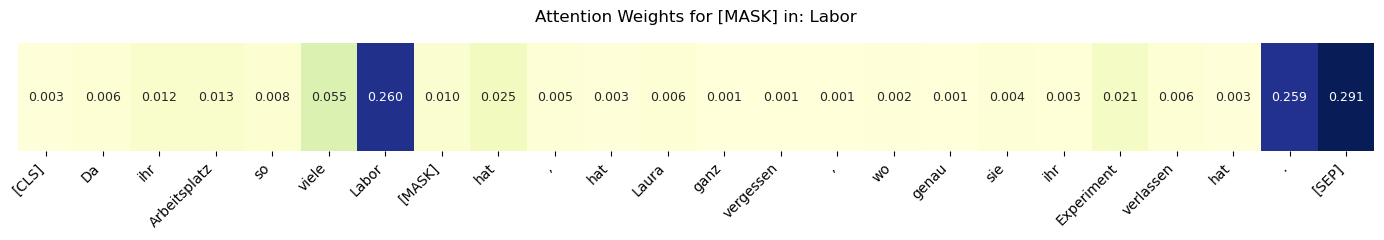

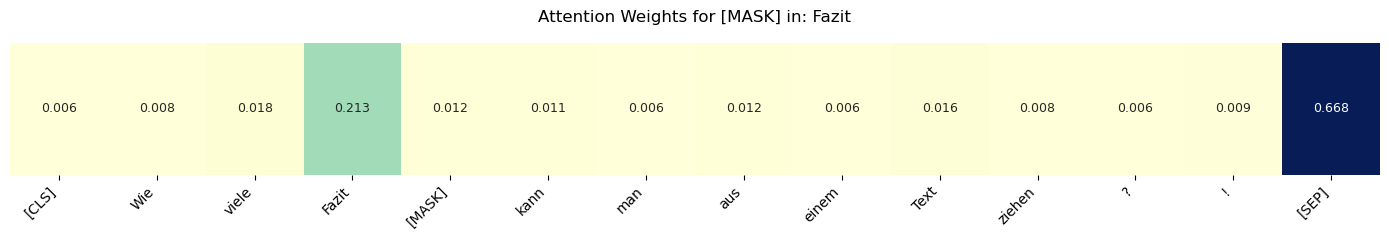

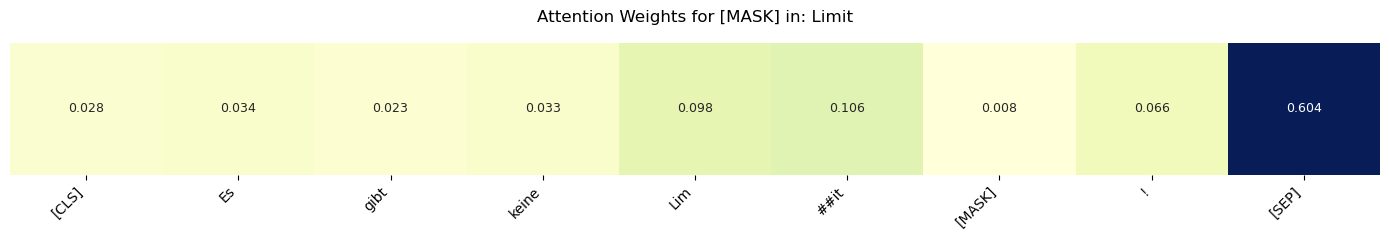

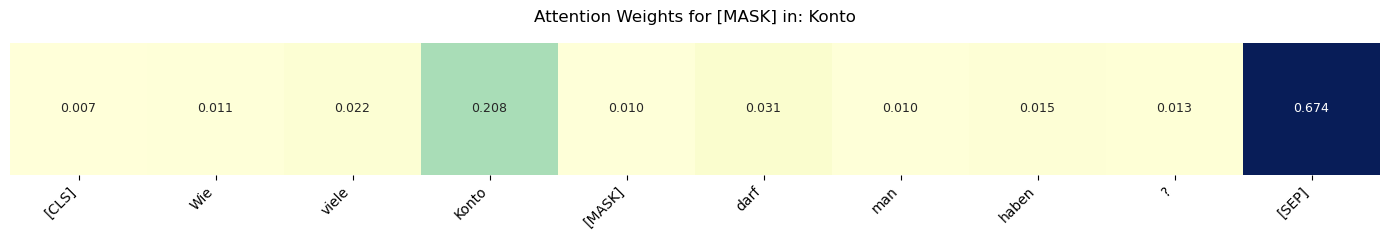

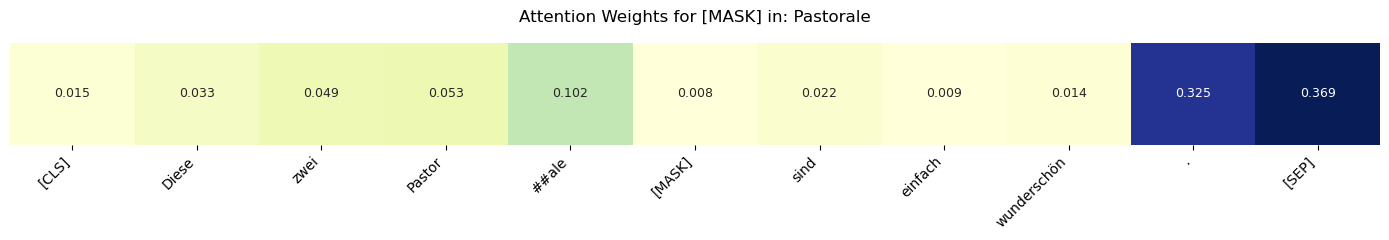

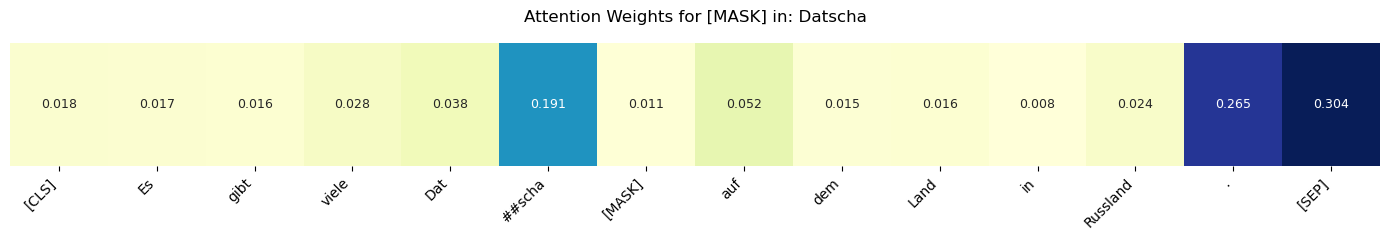

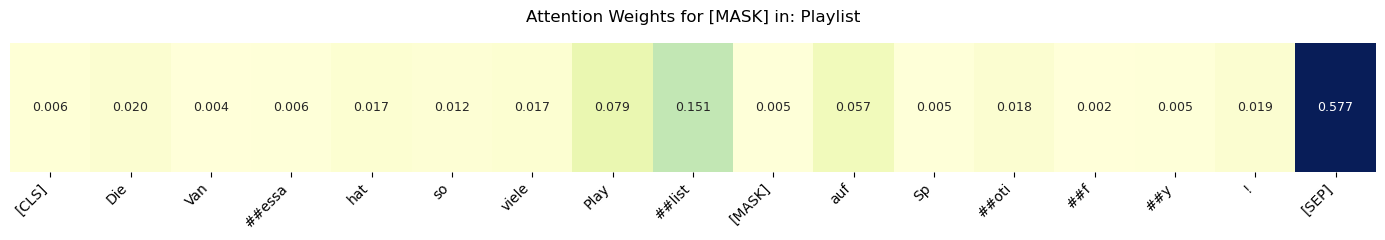

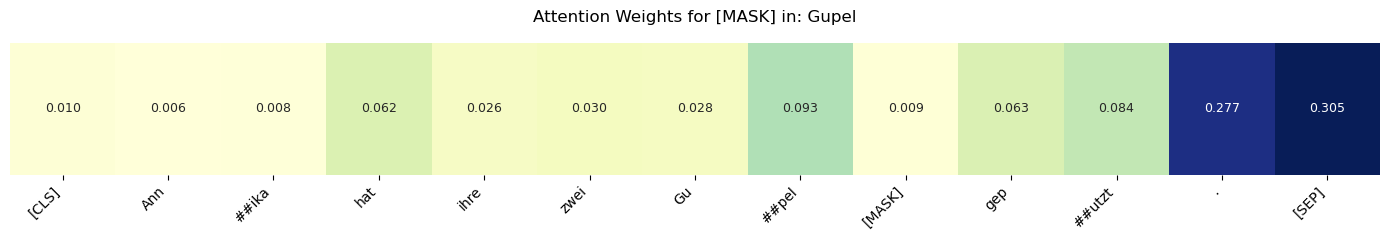

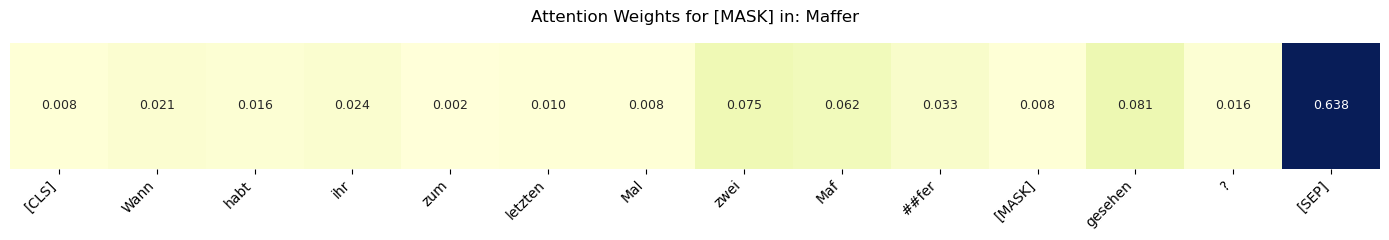

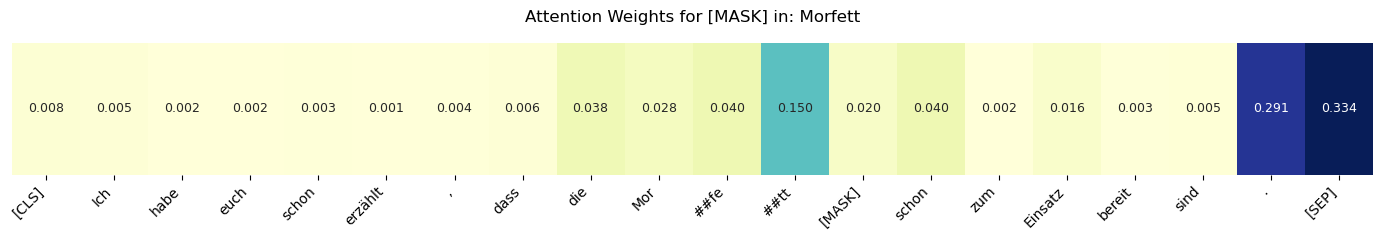

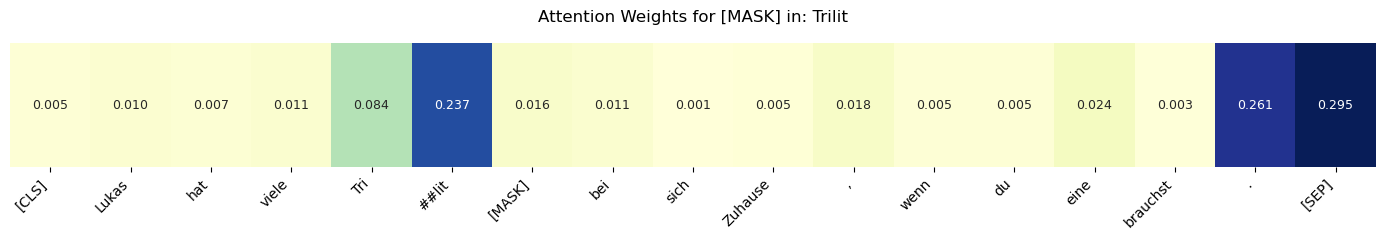

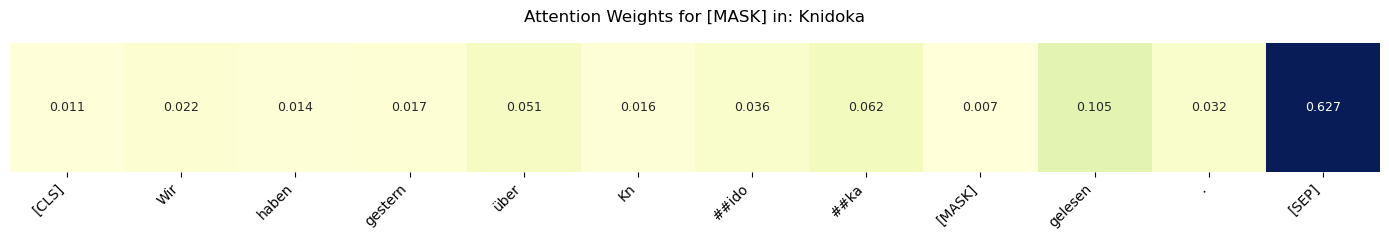

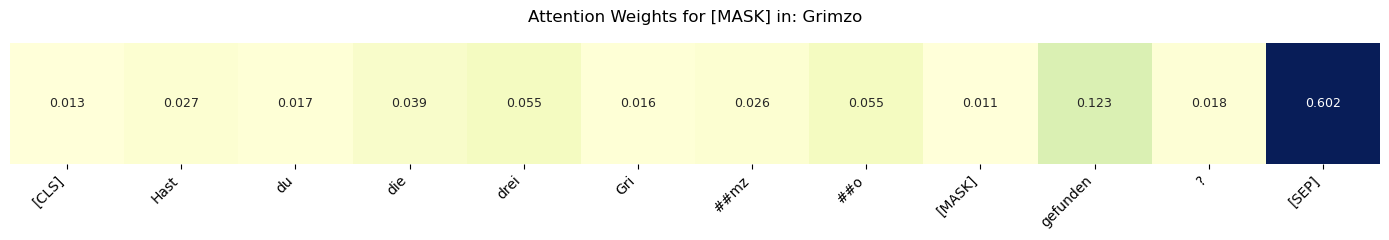

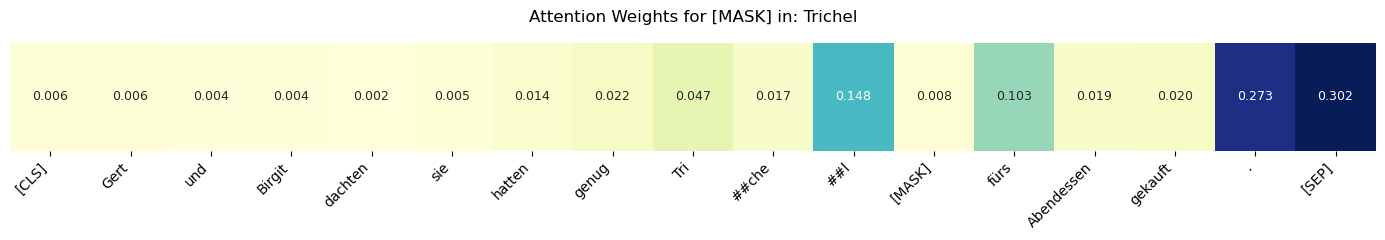

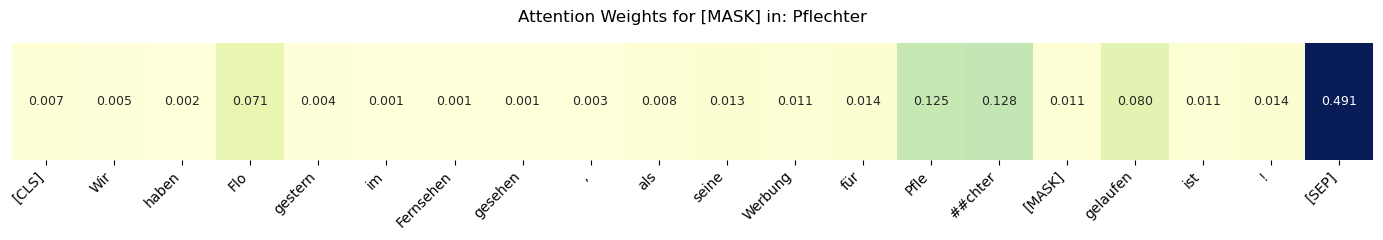

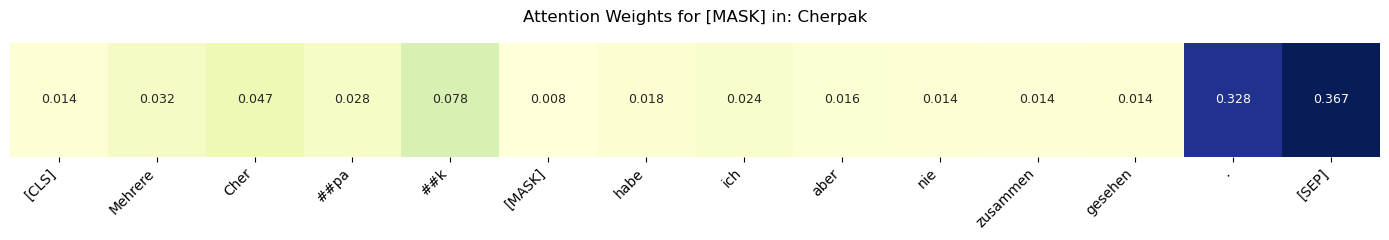

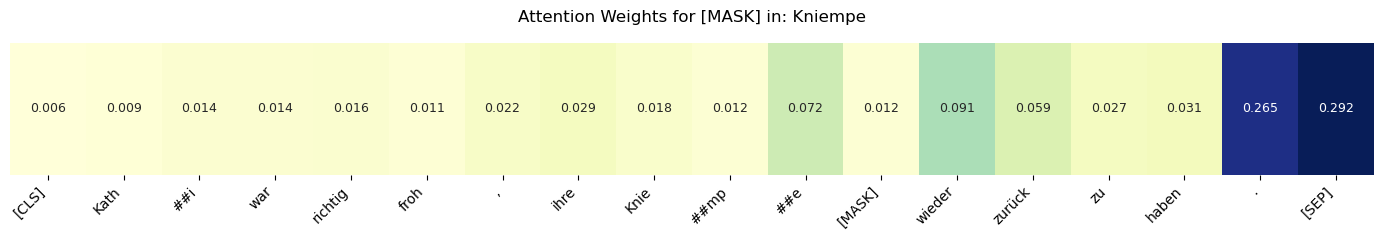

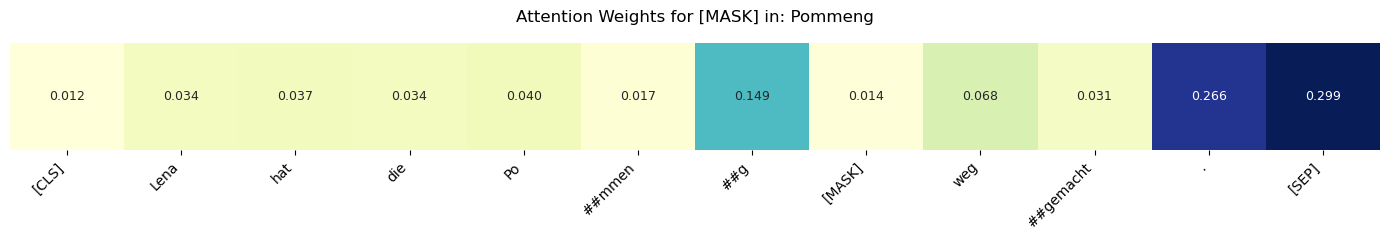

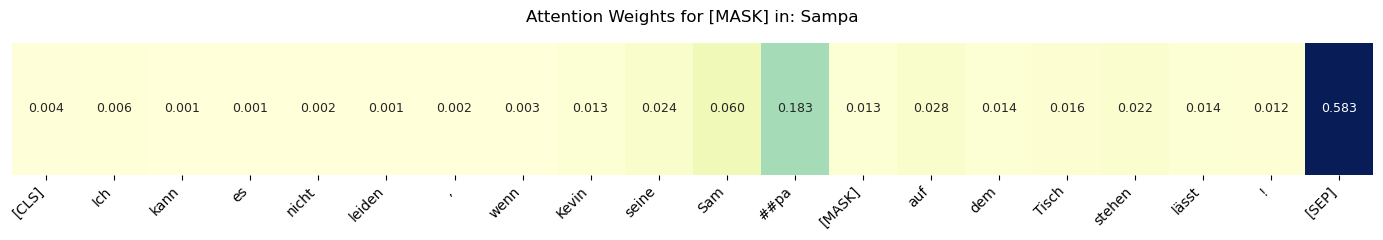

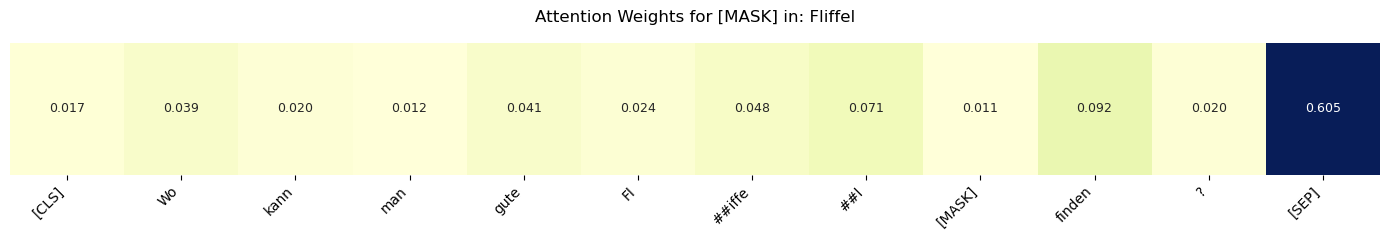

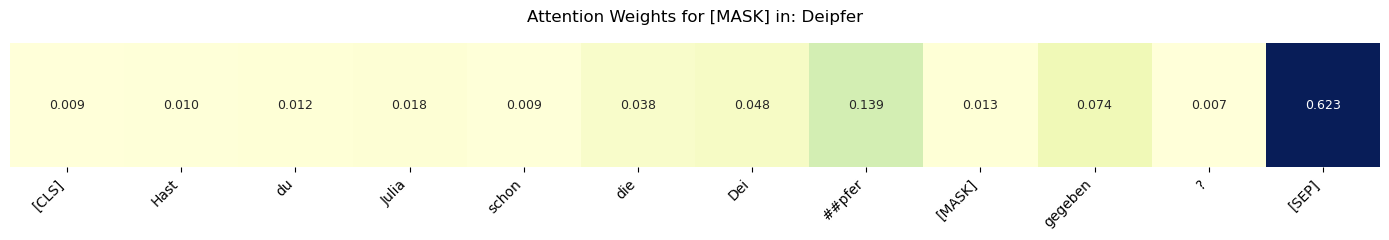

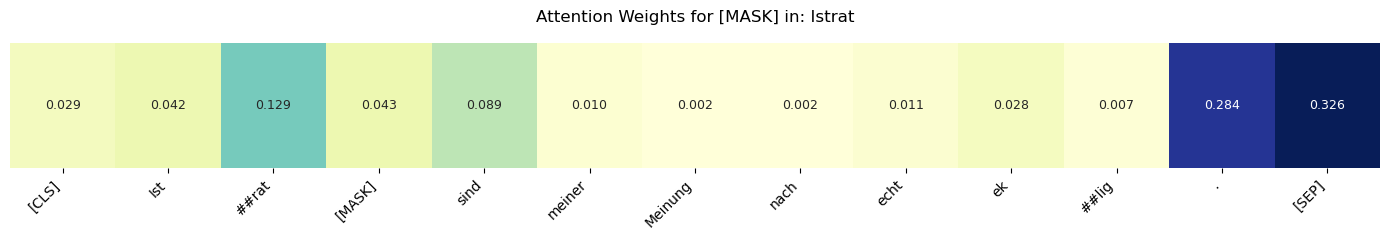

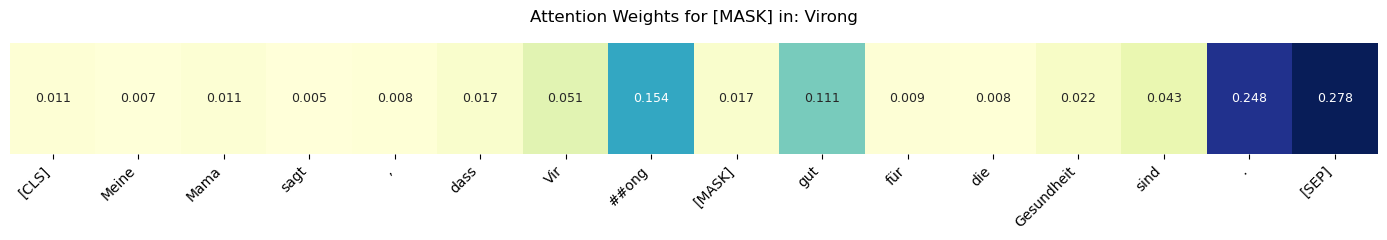

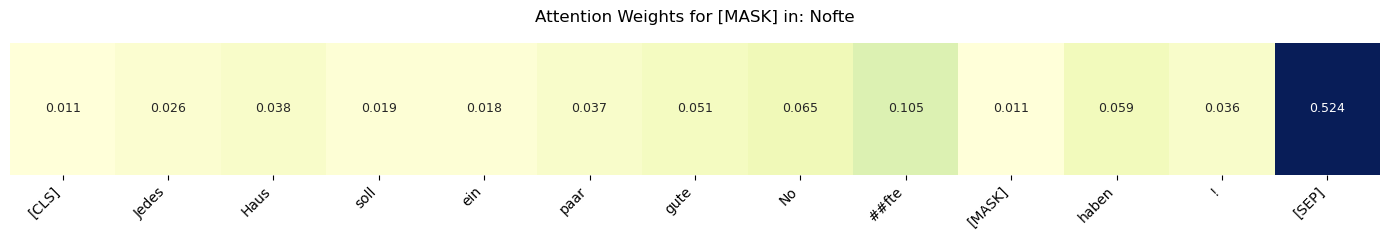

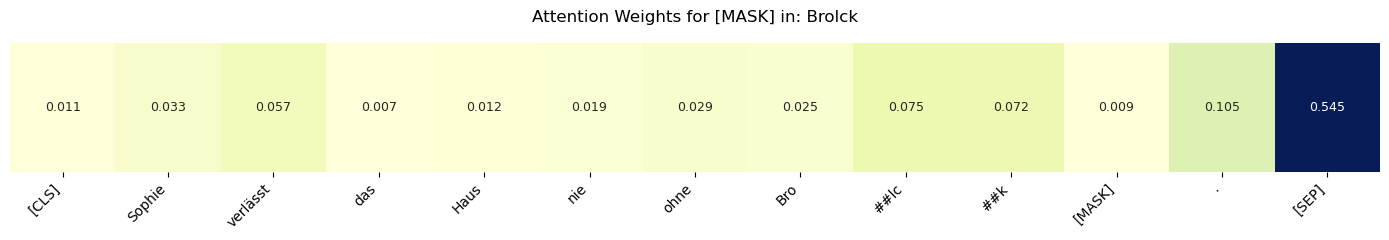

In [ ]:
# Run
for lemma, info in plural_stimuli.items():
    plot_tokenized_sentence_attention(lemma, info["cloze"])